In [ ]:
import os
import random
import numpy as np
from numpy import array, ndarray
from pandas import DataFrame, read_excel
from typing import Literal
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.pyplot import (figure, subplots, show, gca)
from matplotlib.ticker import MultipleLocator
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))
from Library.dslabs_functions import (plot_bar_chart, plot_evaluation_results, CLASS_EVAL_METRICS, DELTA_IMPROVE, read_train_test_from_df)

In [2]:
def plot_model_evaluation(model, trnX, trnY, tstX, tstY, labels, params):
    prd_trn = model.predict(trnX)
    prd_tst = model.predict(tstX)
    figure()
    plot_evaluation_results(params, trnY, prd_trn, tstY, prd_tst, labels)
    fig = gca().figure
    for ax in fig.axes:
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.5)
            spine.set_color("black")
        if ax.images:
            for im in ax.images:
                im.set_cmap("Blues")
            ax.set_title("")
        else:
            ax.set_ylim(0.6, 1.02)
            ax.legend(
                    loc="lower right",
                    fontsize=8,
                    handlelength=1.2,
                    handletextpad=0.4,
                    borderpad=0.3,
                    labelspacing=0.3,
                    framealpha=0.9,
                )
        for text in ax.texts:
            text.set_color("black")
        ax.tick_params(direction="out")
    show()

`Train and Test Files`

In [ ]:
HEIGHT = 4
#SEED = np.random.randint(0, 2**32)
#print(SEED)
SEED = 1814912441
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [5]:
filename = "../DataBase/DataCollection.xlsx"

dataset_train: DataFrame = read_excel(filename, sheet_name= "895 Train Split")
dataset_test: DataFrame = read_excel(filename, sheet_name= "895 Test Split")
target = "Dissolution"

In [8]:
trnX, tstX, trnY, tstY, labels, vars = read_train_test_from_df(dataset_train, dataset_test, target)
print(f"Train#={len(trnX)}  Test#={len(tstX)}")

Train#=714  Test#=269


`Evaluation Metric for all Models`

In [29]:
# accuracy
# precision
# f1
# auc
# recall

eval_metric = "Accuracy"

`Naive-Bayes Models`

Estimator        Train Accuracy   Test Accuracy
-----------------------------------------------
Gaussian                 0.5126          0.4275
Multinomial              0.7983          0.8253
Bernoulli                0.7493          0.7732
-----------------------------------------------
Best: Multinomial                          0.8253


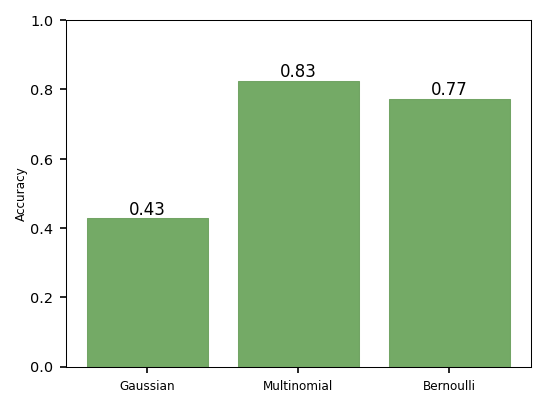

In [30]:
def naive_Bayes_study(
    trnX: ndarray,
    trnY: array,
    tstX: ndarray,
    tstY: array,
    metric: str = "Accuracy",
) -> tuple:
    estimators: dict = {
        "Gaussian": GaussianNB(),
        "Multinomial": MultinomialNB(),
        "Bernoulli": BernoulliNB(),
    }

    xvalues: list = []
    yvalues: list = []
    best_model = None
    best_params: dict = {"name": "", "metric": metric, "params": ()}
    best_performance = 0

    print(f"{'Estimator':<15} {'Train '+metric:>15} {'Test '+metric:>15}")
    print("-" * 47)

    for clf in estimators:
        xvalues.append(clf)
        estimators[clf].fit(trnX, trnY)

        prdY_trn: array = estimators[clf].predict(trnX)   
        prdY_tst: array = estimators[clf].predict(tstX)   

        eval_trn: float = CLASS_EVAL_METRICS[metric](trnY, prdY_trn)
        eval_tst: float = CLASS_EVAL_METRICS[metric](tstY, prdY_tst)

        print(f"{clf:<15} {eval_trn:>15.4f} {eval_tst:>15.4f}")

        yvalues.append(eval_tst)

        if eval_tst - best_performance > DELTA_IMPROVE:
            best_performance = eval_tst
            best_params["name"] = clf
            best_params[metric] = eval_tst
            best_model = estimators[clf]

    print("-" * 47)
    print(f"{'Best: '+best_params['name']:<15} {'':>15} {best_performance:>15.4f}")

    plot_bar_chart(
        xvalues,
        yvalues,
        title="",
        ylabel=metric,
        percentage=True,
    )

    ax = gca()
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color("black")

    ax.tick_params(direction="out")
    return best_model, best_params

figure()
best_model, params = naive_Bayes_study(trnX, trnY, tstX, tstY, eval_metric)
show()

<Figure size 600x450 with 0 Axes>

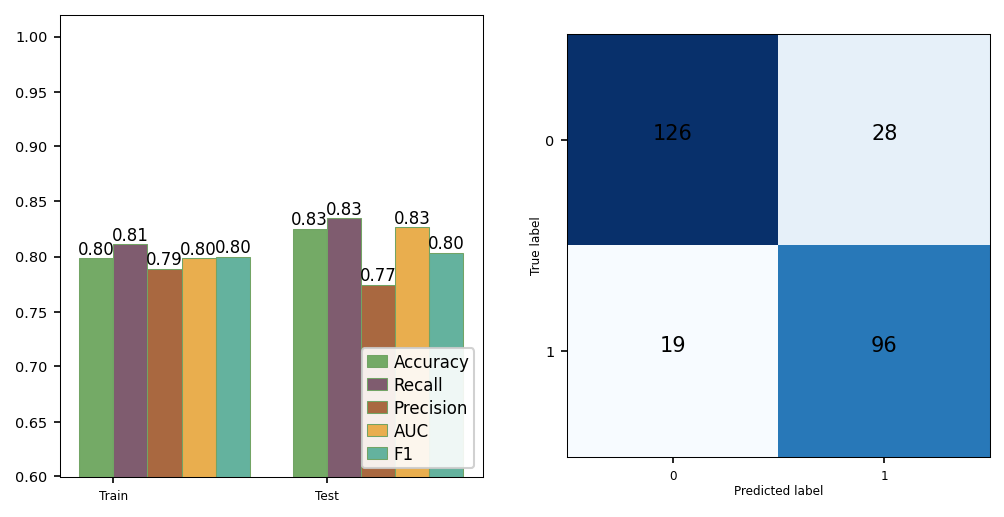

In [31]:
plot_model_evaluation(best_model, trnX, trnY, tstX, tstY, labels, params)

`KNN Models`

k     Distance      Train Accuracy   Test Accuracy
-------------------------------------------------
1     manhattan             1.0000          0.9108
3     manhattan             0.9552          0.8662
5     manhattan             0.9244          0.8736
7     manhattan             0.9076          0.8439
9     manhattan             0.8880          0.8401
11    manhattan             0.8810          0.8364
13    manhattan             0.8697          0.8327
15    manhattan             0.8529          0.8290
17    manhattan             0.8487          0.8327
19    manhattan             0.8473          0.8439
21    manhattan             0.8403          0.8327
23    manhattan             0.8403          0.8364
25    manhattan             0.8361          0.8327
1     euclidean             1.0000          0.9182
3     euclidean             0.9552          0.8736
5     euclidean             0.9174          0.8625
7     euclidean             0.9048          0.8513
9     euclidean             0.88

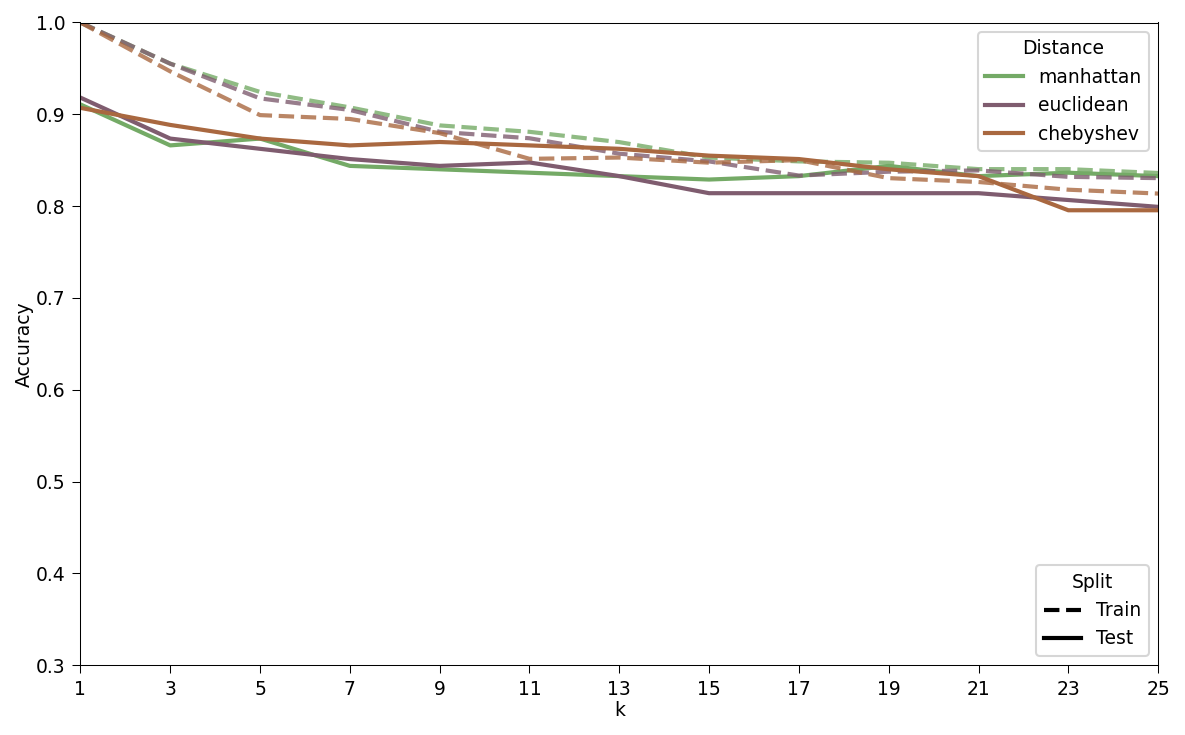

In [32]:
def knn_study(
    trnX: ndarray,
    trnY: array,
    tstX: ndarray,
    tstY: array,
    k_max: int,
    lag: int,
    metric: str = "Accuracy",
) -> tuple[KNeighborsClassifier | None, dict]:

    dist = ["manhattan", "euclidean", "chebyshev"]
    kvalues = list(range(1, k_max + 1, lag))
    colors = {"manhattan": "#74aa66", "euclidean": "#7F5C6F", "chebyshev": "#A96840"}

    best_model, best_params, best_performance = None, {"name": "KNN", "metric": metric, "params": ()}, 0.0
    values_tst, values_trn = {}, {}

    print(f"{'k':<5} {'Distance':<12} {'Train '+metric:>15} {'Test '+metric:>15}")
    print("-" * 49)

    for d in dist:
        y_tst_values, y_trn_values = [], []
        for k in kvalues:
            clf = KNeighborsClassifier(n_neighbors=k, metric=d)
            clf.fit(trnX, trnY)
            eval_trn = CLASS_EVAL_METRICS[metric](trnY, clf.predict(trnX))
            eval_tst = CLASS_EVAL_METRICS[metric](tstY, clf.predict(tstX))
            y_trn_values.append(eval_trn)
            y_tst_values.append(eval_tst)
            print(f"{k:<5} {d:<12} {eval_trn:>15.4f} {eval_tst:>15.4f}")

            if eval_tst - best_performance > DELTA_IMPROVE:
                best_performance = eval_tst
                best_params["params"] = (k, d)
                best_model = clf

        values_tst[d] = y_tst_values
        values_trn[d] = y_trn_values

    fig, ax = subplots(figsize=(8, 5))

    for d in dist:
        ax.plot(kvalues, values_trn[d], linestyle="--", color=colors[d], alpha=0.8)
        ax.plot(kvalues, values_tst[d], linestyle="-", color=colors[d], alpha=1.0)

    ax.set(xlabel="k", ylabel=metric, xlim=(1, k_max), ylim=(0.3, 1.0))
    ax.set_xticks(kvalues)
    ax.tick_params(axis="both", which="major", labelsize=9, direction="out", width=0.5, length=4)
    ax.xaxis.label.set_size(9)
    ax.yaxis.label.set_size(9)
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set(visible=True, linewidth=0.5, color="black")

    dist_legend = ax.legend(
        handles=[mlines.Line2D([], [], color=colors[d], lw=2, label=d) for d in dist],
        title="Distance",
        loc="upper right",
        frameon=True,
        fontsize=9,
        title_fontsize=9,
    )
    ax.add_artist(dist_legend)

    ax.legend(
        handles=[
            mlines.Line2D([], [], color="black", linestyle="--", lw=2, label="Train"),
            mlines.Line2D([], [], color="black", linestyle="-", lw=2, label="Test"),
        ],
        title="Split",
        loc="lower right",
        frameon=True,
        fontsize=9,
        title_fontsize=9,
    )

    fig.tight_layout()
    return best_model, best_params


best_model, params = knn_study(
    trnX,
    trnY,
    tstX,
    tstY,
    k_max=25,
    metric=eval_metric,
    lag=2,
)
show()

In [33]:
best_k = 9
best_distance = "chebyshev"

<Figure size 600x450 with 0 Axes>

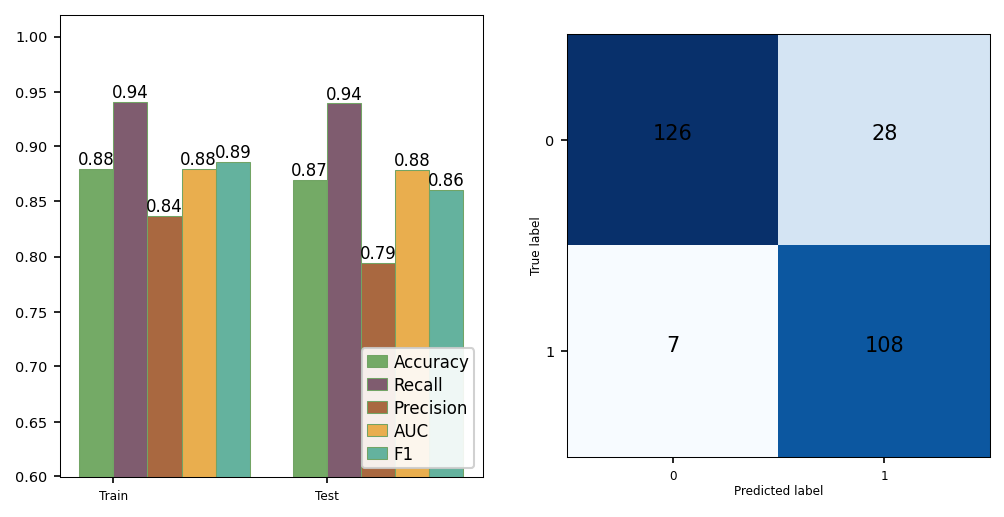

In [34]:
best_model = KNeighborsClassifier(n_neighbors=best_k, metric=best_distance)
best_model.fit(trnX, trnY)
best_params = {"name": "KNN", "metric": eval_metric, "params": (best_k, best_distance)}
plot_model_evaluation(best_model, trnX, trnY, tstX, tstY, labels, best_params)

`Support Vector Machines`

Kernel       Iterations  Train Accuracy   Test Accuracy
------------------------------------------------------
Sigmoid              25          0.5126          0.4312
Sigmoid              50          0.5098          0.4349
Sigmoid              75          0.4468          0.3941
Sigmoid             100          0.4902          0.4349
Sigmoid             125          0.5910          0.5911
Sigmoid             150          0.6176          0.6283
Sigmoid             175          0.6331          0.6208
Sigmoid             200          0.6471          0.6059
Sigmoid             225          0.6162          0.6022
Sigmoid             250          0.6246          0.6468
Sigmoid             275          0.6373          0.6357
Sigmoid             300          0.6471          0.6580
Sigmoid             325          0.6499          0.6468
Sigmoid             350          0.6499          0.6468
Sigmoid             375          0.6499          0.6468
Sigmoid             400          0.6499          

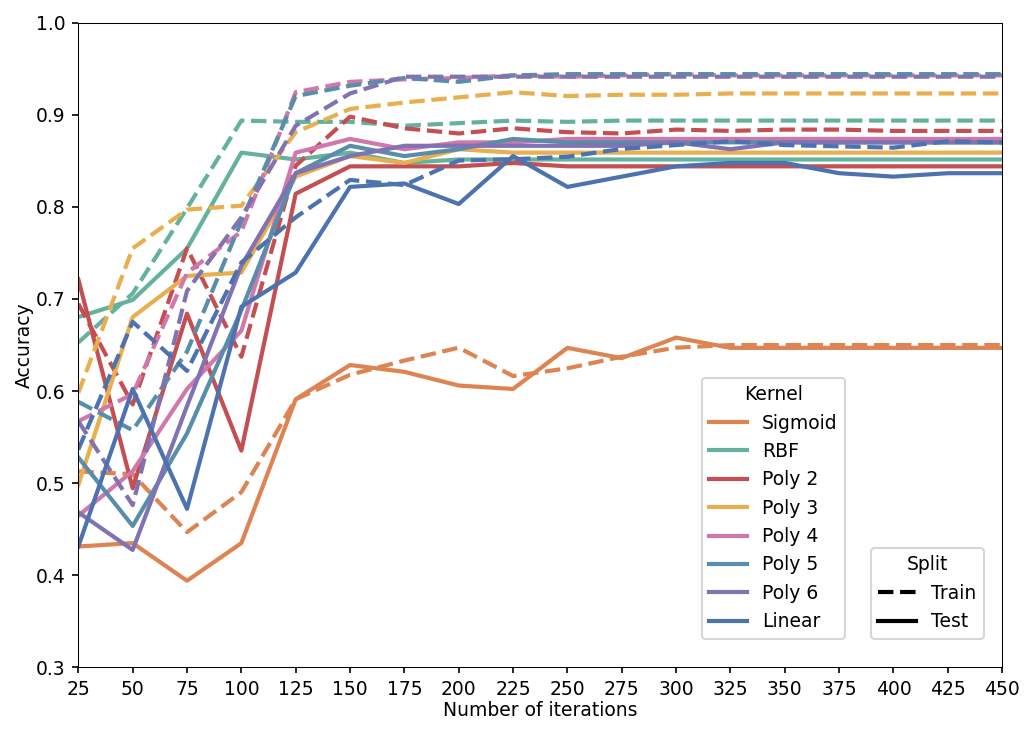

In [35]:
def svm_study(
    trnX: ndarray,
    trnY: array,
    tstX: ndarray,
    tstY: array,
    nr_max_iterations: int,
    lag: int,
    metric: str = "Accuracy",
    plot_kernels: list[str] = None,
) -> None:

    nr_iterations = list(range(25, nr_max_iterations + 1, lag))
    if nr_iterations[-1] != nr_max_iterations:
        nr_iterations.append(nr_max_iterations)

    kernel_types = ["sigmoid", "rbf", "poly", "linear"]
    poly_degrees = [2, 3, 4, 5, 6, 7, 8]
    colors = {
        "Linear": "#4C72B0",
        "Sigmoid": "#DD8452",
        "RBF": "#64B29E",
        "Poly 2": "#C44E52",
        "Poly 3": "#E9AE4E",
        "Poly 4": "#D077AC",
        "Poly 5": "#588EAA",
        "Poly 6": "#8172B2",
        "Poly 7": "#F09E64",
        "Poly 8": "#CABE57",
    }

    values_train, values_test = {}, {}

    print(f"{'Kernel':<12} {'Iterations':>10} {'Train '+metric:>15} {'Test '+metric:>15}")
    print("-" * 54)

    for kernel in kernel_types:
        degrees = poly_degrees if kernel == "poly" else [0]

        for d in degrees:
            label = "RBF" if kernel == "rbf" else f"Poly {d}" if kernel == "poly" else kernel.capitalize()
            train_values, test_values = [], []

            for n in nr_iterations:
                clf = SVC(
                    kernel=kernel,
                    max_iter=n,
                    degree=d,
                    verbose=False,
                    random_state=SEED,
                )
                clf.fit(trnX, trnY)

                train_score = CLASS_EVAL_METRICS[metric](trnY, clf.predict(trnX))
                test_score = CLASS_EVAL_METRICS[metric](tstY, clf.predict(tstX))

                train_values.append(train_score)
                test_values.append(test_score)

                print(f"{label:<12} {n:>10} {train_score:>15.4f} {test_score:>15.4f}")

            values_train[label] = train_values
            values_test[label] = test_values

    to_plot = plot_kernels if plot_kernels is not None else list(values_test.keys())

    fig, ax = subplots(figsize=(7, 5))

    for label in to_plot:
        ax.plot(nr_iterations, values_test[label], color=colors[label], linestyle="-", label=label)
        ax.plot(nr_iterations, values_train[label], color=colors[label], linestyle="--")

    ax.set_xlabel("Number of iterations", fontsize=9)
    ax.set_ylabel(metric, fontsize=9)
    ax.set_xlim(25, nr_max_iterations)
    ax.set_ylim(0.3, 1.0)
    ax.set_xticks(nr_iterations)
    ax.set_xticklabels([str(x) for x in nr_iterations], fontsize=9)
    ax.set_yticklabels([f"{y:.1f}" for y in ax.get_yticks()], fontsize=9)
    ax.grid(False)
    ax.tick_params(axis="both", which="major", labelsize=9, direction="out")

    for spine in ax.spines.values():
        spine.set(visible=True, linewidth=0.5, color="black")

    kernel_legend = ax.legend(
        title="Kernel",
        fontsize=9,
        title_fontsize=9,
        loc="lower right",
        bbox_to_anchor=(0.84, 0.03),
    )
    ax.add_artist(kernel_legend)

    ax.legend(
        handles=[
            Line2D([0], [0], color="black", linestyle="--", label="Train"),
            Line2D([0], [0], color="black", linestyle="-", label="Test"),
        ],
        title="Split",
        fontsize=9,
        title_fontsize=9,
        loc="lower right",
        bbox_to_anchor=(0.99, 0.03),
    )

    fig.tight_layout()


svm_study(
    trnX,
    trnY,
    tstX,
    tstY,
    nr_max_iterations=450,
    lag=25,
    metric=eval_metric,
    plot_kernels=["Sigmoid", "RBF", "Poly 2", "Poly 3", "Poly 4", "Poly 5", "Poly 6", "Linear"],
)
show()

Kernel       Iterations  Train Accuracy   Test Accuracy
------------------------------------------------------
Sigmoid              25          0.5126          0.4312
Sigmoid              50          0.5098          0.4349
Sigmoid              75          0.4468          0.3941
Sigmoid             100          0.4902          0.4349
Sigmoid             125          0.5910          0.5911
Sigmoid             150          0.6176          0.6283
Sigmoid             175          0.6331          0.6208
Sigmoid             200          0.6471          0.6059
Sigmoid             225          0.6162          0.6022
Sigmoid             250          0.6246          0.6468
Sigmoid             275          0.6373          0.6357
Sigmoid             300          0.6471          0.6580
Sigmoid             325          0.6499          0.6468
Sigmoid             350          0.6499          0.6468
Sigmoid             375          0.6499          0.6468
Sigmoid             400          0.6499          

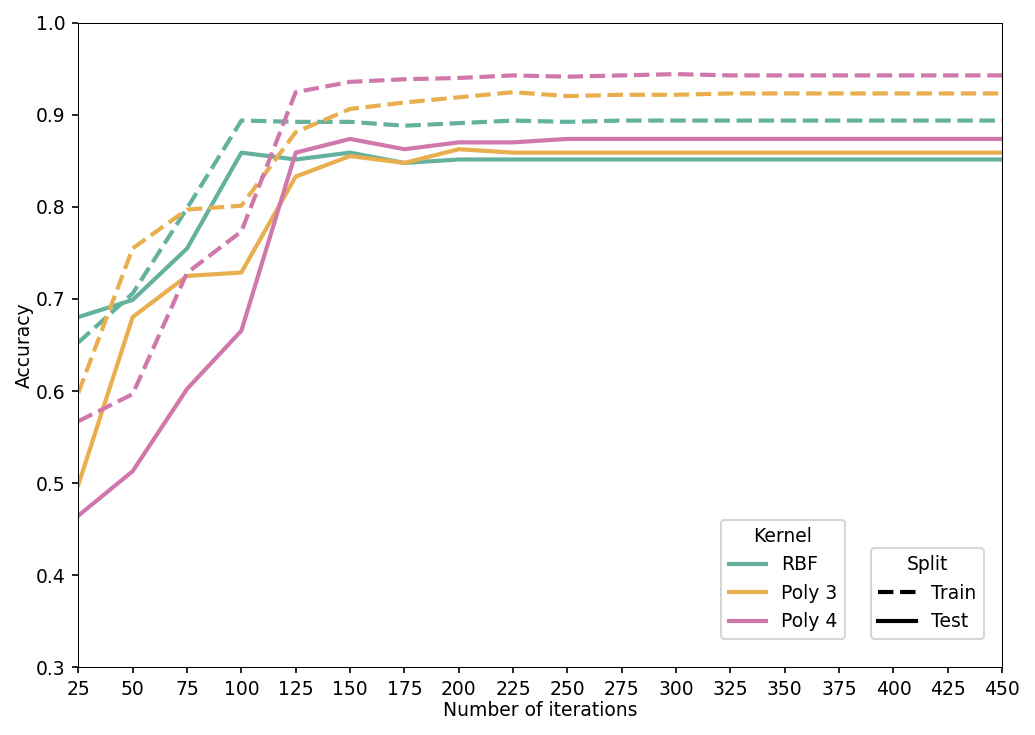

In [36]:
svm_study(trnX, trnY, tstX, tstY, nr_max_iterations=450, lag=25, metric=eval_metric, plot_kernels=["RBF", "Poly 3", "Poly 4"])
show()

Kernel       Iterations  Train Accuracy   Test Accuracy
------------------------------------------------------
Sigmoid              25          0.5126          0.4312
Sigmoid              50          0.5098          0.4349
Sigmoid              75          0.4468          0.3941
Sigmoid             100          0.4902          0.4349
Sigmoid             125          0.5910          0.5911
Sigmoid             150          0.6176          0.6283
Sigmoid             175          0.6331          0.6208
Sigmoid             200          0.6471          0.6059
Sigmoid             225          0.6162          0.6022
Sigmoid             250          0.6246          0.6468
Sigmoid             275          0.6373          0.6357
Sigmoid             300          0.6471          0.6580
Sigmoid             325          0.6499          0.6468
Sigmoid             350          0.6499          0.6468
Sigmoid             375          0.6499          0.6468
Sigmoid             400          0.6499          

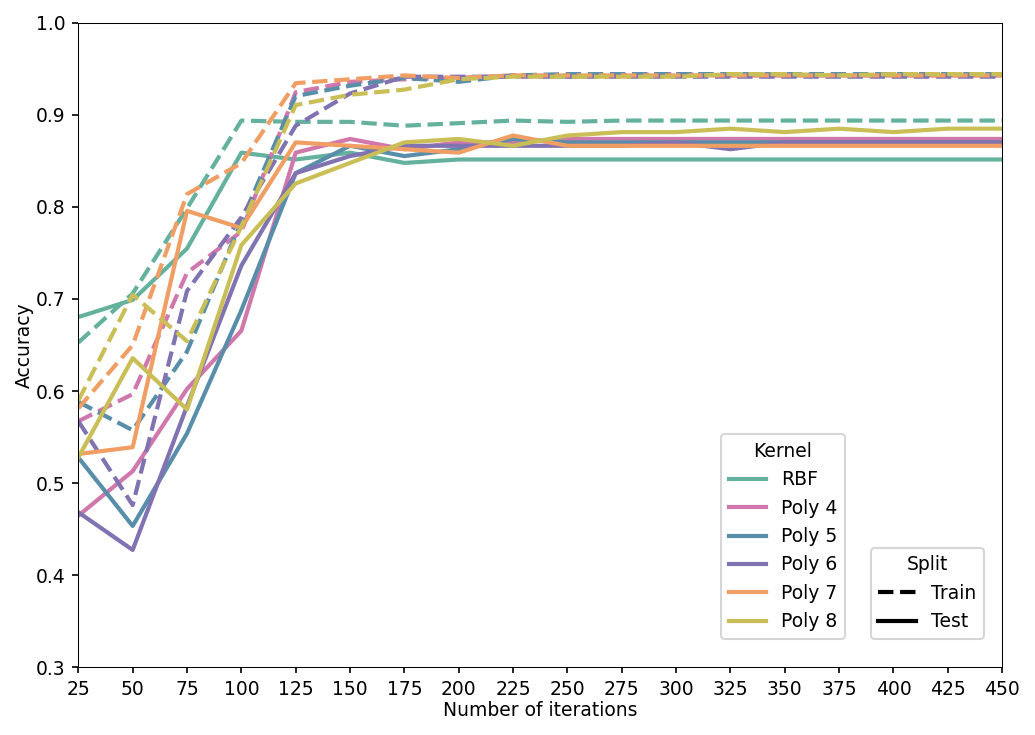

In [37]:
svm_study(trnX, trnY, tstX, tstY, nr_max_iterations=450, lag=25, metric=eval_metric, plot_kernels=["RBF", "Poly 4", "Poly 5", "Poly 6", "Poly 7", "Poly 8"])
show()

In [38]:
chosen_kernel = "rbf"   
chosen_degree = 0       
chosen_iter   = 250    

<Figure size 600x450 with 0 Axes>

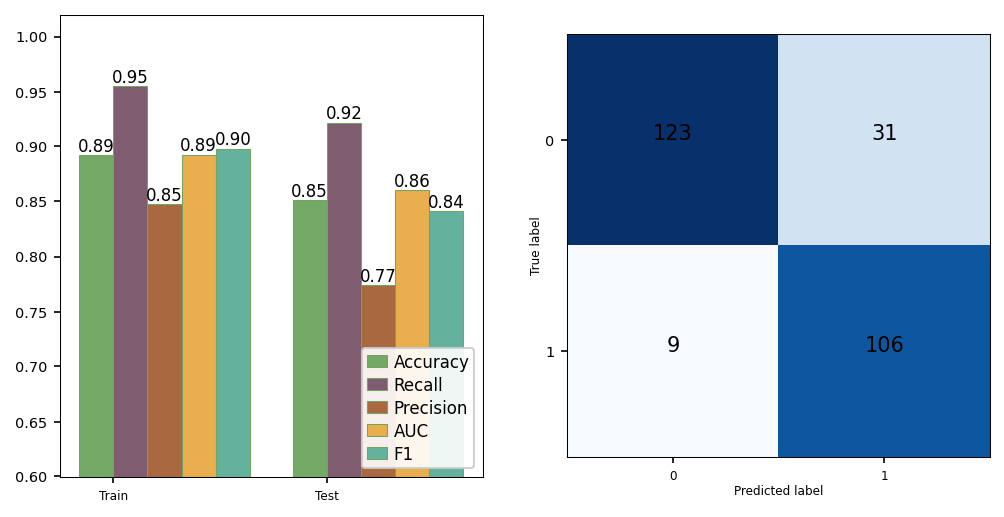

In [39]:
chosen_model = SVC(kernel=chosen_kernel, max_iter=chosen_iter, degree=chosen_degree, random_state=SEED)
chosen_model.fit(trnX, trnY)
chosen_params = {"name": "SVM", "metric": eval_metric, "params": (chosen_kernel, chosen_iter, chosen_degree)}

plot_model_evaluation(chosen_model, trnX, trnY, tstX, tstY, labels, chosen_params)

`Decision Trees Models`

Criterion     Depth  Train Accuracy   Test Accuracy
--------------------------------------------------
entropy           2          0.7213          0.7546
entropy           4          0.8319          0.8401
entropy           6          0.8922          0.8810
entropy           8          0.9286          0.8922
entropy          10          0.9692          0.9108
entropy          12          0.9832          0.9033
entropy          14          0.9958          0.9108

gini              2          0.7213          0.7546
gini              4          0.8515          0.8513
gini              6          0.8978          0.8885
gini              8          0.9286          0.8885
gini             10          0.9566          0.9071
gini             12          0.9776          0.9108
gini             14          0.9930          0.9071



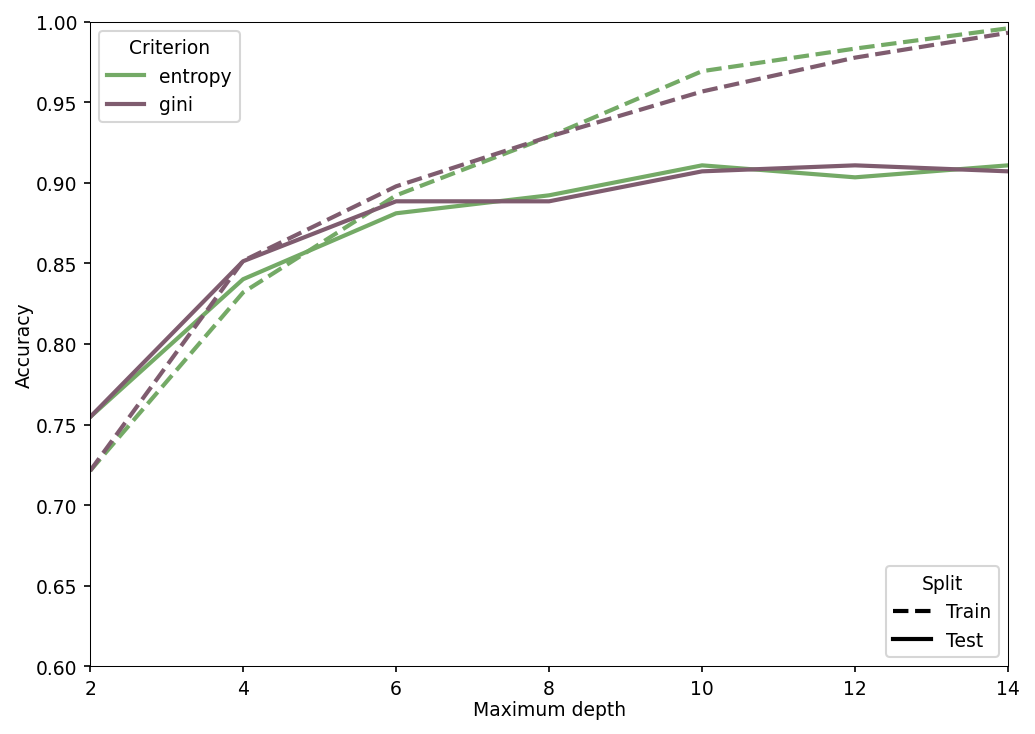

In [40]:
def trees_study(
    trnX: ndarray,
    trnY: array,
    tstX: ndarray,
    tstY: array,
    d_max: int,
    lag: int,
    metric: str = "Accuracy",
) -> None:

    criteria = ["entropy", "gini"]
    depths = list(range(2, d_max + 1, lag))
    colors = {"entropy": "#74aa66", "gini": "#7F5C6F"}

    values_train, values_test = {}, {}

    print(f"{'Criterion':<12} {'Depth':>6} {'Train '+metric:>15} {'Test '+metric:>15}")
    print("-" * 50)

    for c in criteria:
        y_trn_values, y_tst_values = [], []

        for d in depths:
            clf = DecisionTreeClassifier(max_depth=d, criterion=c, random_state=SEED)
            clf.fit(trnX, trnY)

            eval_trn = CLASS_EVAL_METRICS[metric](trnY, clf.predict(trnX))
            eval_tst = CLASS_EVAL_METRICS[metric](tstY, clf.predict(tstX))

            y_trn_values.append(eval_trn)
            y_tst_values.append(eval_tst)

            print(f"{c:<12} {d:>6} {eval_trn:>15.4f} {eval_tst:>15.4f}")

        values_train[c] = y_trn_values
        values_test[c] = y_tst_values

        print()

    fig, ax = subplots(figsize=(7, 5))

    for c in criteria:
        ax.plot(depths, values_test[c], color=colors[c], linestyle="-", label=c)
        ax.plot(depths, values_train[c], color=colors[c], linestyle="--")

    ax.set(xlabel="Maximum depth", ylabel=metric, xlim=(2, d_max), ylim=(0.6, 1.0))
    ax.set_xticks(depths)
    ax.tick_params(axis="both", which="major", labelsize=9, direction="out")
    ax.xaxis.label.set_size(9)
    ax.yaxis.label.set_size(9)
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set(visible=True, linewidth=0.5, color="black")

    criterion_legend = ax.legend(
        title="Criterion",
        fontsize=9,
        title_fontsize=9,
        loc="upper left",
    )
    ax.add_artist(criterion_legend)

    ax.legend(
        handles=[
            Line2D([0], [0], color="black", linestyle="--", label="Train"),
            Line2D([0], [0], color="black", linestyle="-", label="Test"),
        ],
        title="Split",
        fontsize=9,
        title_fontsize=9,
        loc="lower right",
    )

    fig.tight_layout()


trees_study(
    trnX,
    trnY,
    tstX,
    tstY,
    d_max=14,
    lag=2,
    metric=eval_metric,
)
show()

In [41]:
best_criterion = "gini" 
best_depth = 6         

<Figure size 600x450 with 0 Axes>

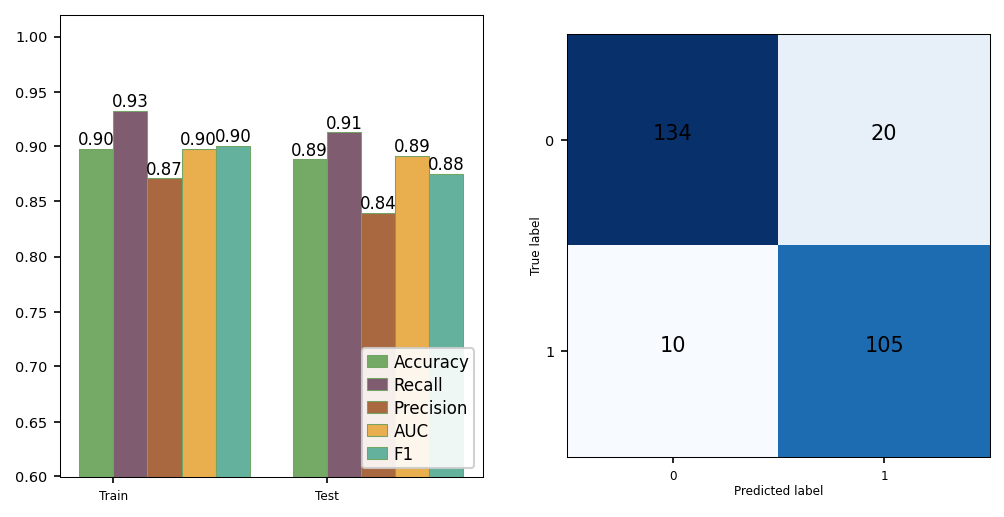

In [42]:
best_model = DecisionTreeClassifier(max_depth=best_depth, criterion=best_criterion, random_state=SEED)
best_model.fit(trnX, trnY)
params = {"name": "DT", "metric": eval_metric, "params": (best_criterion, best_depth)}
plot_model_evaluation(best_model, trnX, trnY, tstX, tstY, labels, params)

`Random Forests`

 Depth   Features   N Estimators  Train Accuracy   Test Accuracy
--------------------------------------------------------------
     2        0.1              5            0.78            0.77
     2        0.1             10            0.80            0.83
     2        0.1             15            0.78            0.80
     2        0.1             20            0.77            0.78
     2        0.1             25            0.77            0.79
     2        0.1             30            0.77            0.78
     2        0.1             35            0.78            0.79
     2        0.1             40            0.78            0.79
     2        0.1             45            0.78            0.78
     2        0.1             50            0.78            0.79
     2        0.1             55            0.78            0.78
     2        0.1             60            0.78            0.78
     2        0.1             65            0.78            0.79
     2        0.1          

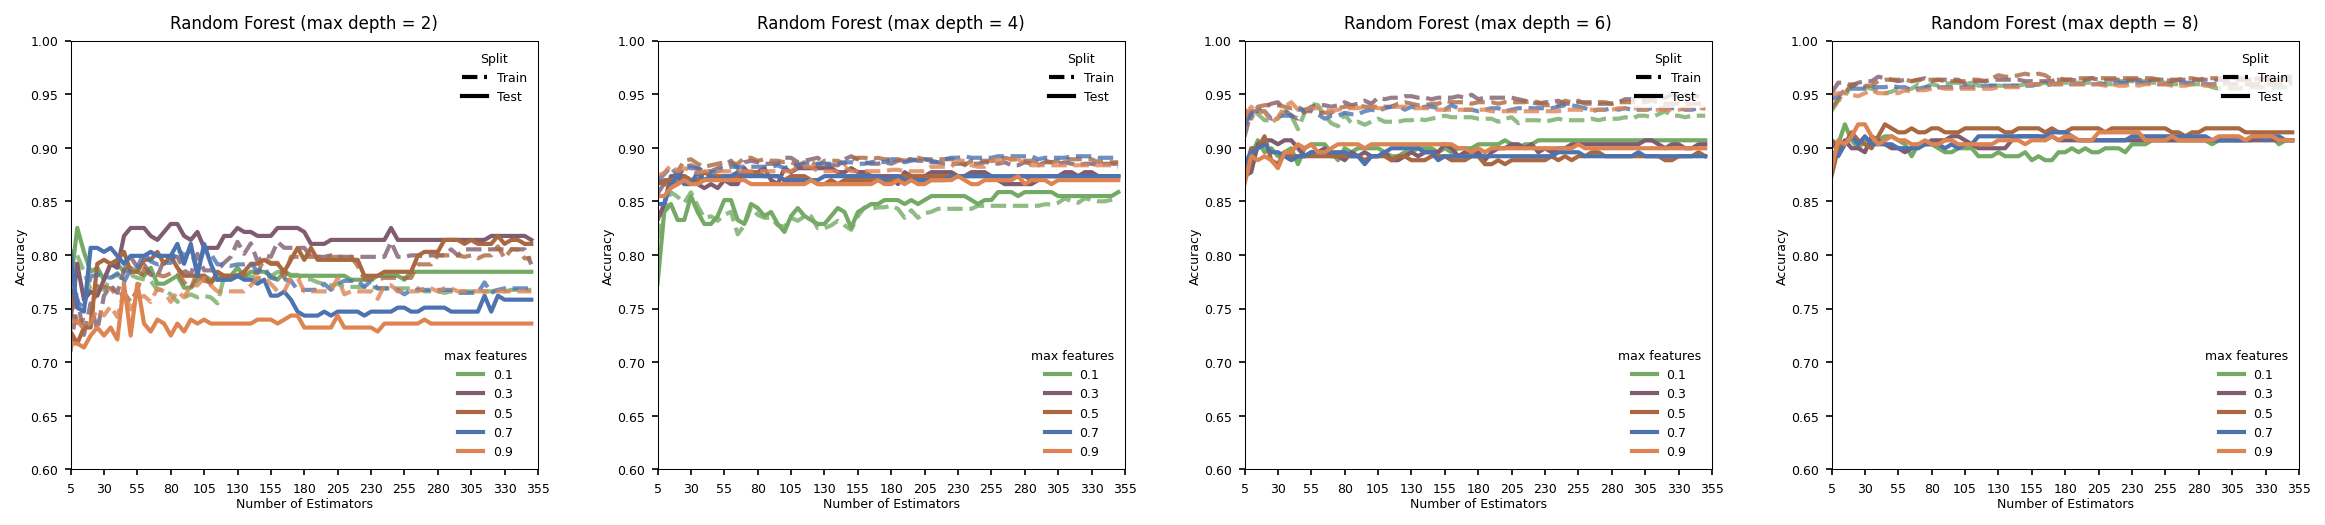

In [ ]:
def random_forests_study(
    trnX: ndarray,
    trnY: array,
    tstX: ndarray,
    tstY: array,
    nr_max_trees: int = 350,
    lag: int = 5,
    metric: str = "Accuracy",
) -> None:

    n_estimators = list(range(5, nr_max_trees + 1, lag))
    if n_estimators[-1] != nr_max_trees:
        n_estimators.append(nr_max_trees)

    max_depths   = [2, 4, 6, 8]
    max_features = [0.1, 0.3, 0.5, 0.7, 0.9]
    colors = {"0.1": "#74aa66", "0.3": "#7F5C6F", "0.5": "#A96840", "0.7": "#4C72B0", "0.9": "#DD8452"}

    print(f"{'Depth':>6} {'Features':>10} {'N Estimators':>14} {'Train '+metric:>15} {'Test '+metric:>15}")
    print("-" * 62)

    cols = len(max_depths)
    _, axs = subplots(1, cols, figsize=(cols * HEIGHT, HEIGHT), squeeze=False)

    for i, d in enumerate(max_depths):
        values_tst, values_trn = {}, {}

        for f in max_features:
            y_tst_values, y_trn_values = [], []

            for n in n_estimators:
                clf = RandomForestClassifier(
                    n_estimators=n, max_depth=d, max_features=f,
                    bootstrap=True, oob_score=True, n_jobs=1, random_state=SEED,
                )
                clf.fit(trnX, trnY)
                eval_trn = CLASS_EVAL_METRICS[metric](trnY, clf.predict(trnX))
                eval_tst = CLASS_EVAL_METRICS[metric](tstY, clf.predict(tstX))
                y_trn_values.append(eval_trn)
                y_tst_values.append(eval_tst)
                print(f"{d:>6} {f:>10.1f} {n:>14} {eval_trn:>15.2f} {eval_tst:>15.2f}")
                
            key = f"{f:.1f}"
            values_tst[key] = y_tst_values
            values_trn[key] = y_trn_values

        print()

        ax = axs[0, i]
        for key in values_tst:
            ax.plot(n_estimators, values_tst[key], color=colors[key], linestyle="-",  linewidth=2, label=key)
            ax.plot(n_estimators, values_trn[key], color=colors[key], linestyle="--", linewidth=2, alpha=0.8)

        ax.set_title(f"Random Forest (max depth = {d})", fontsize=8)
        ax.set(xlabel="Number of Estimators", ylabel=metric, xlim=(5, nr_max_trees), ylim=(0.6, 1.00))
        ax.grid(False)
        ax.tick_params(direction="out", labelsize=6)
        ax.xaxis.label.set_size(6)
        ax.yaxis.label.set_size(6)
        ax.set_facecolor("white")

        for spine in ax.spines.values():
            spine.set(visible=True, linewidth=0.5, color="black")

        feature_legend = ax.legend(
            handles=[mlines.Line2D([], [], color=colors[k], lw=2, label=k) for k in colors],
            title="max features", fontsize=6, title_fontsize=6, loc="lower right", frameon=True,
        )
        feature_legend.get_frame().set_edgecolor("none")
        ax.add_artist(feature_legend)
        split_legend = ax.legend(
            handles=[
                mlines.Line2D([], [], color="black", linestyle="--", lw=2, label="Train"),
                mlines.Line2D([], [], color="black", linestyle="-",  lw=2, label="Test"),
            ],
            title="Split", fontsize=6, title_fontsize=6, loc="upper right", frameon=True,
        )
        split_legend.get_frame().set_edgecolor("none")

    xticks = [5, 30, 55, 80, 105, 130, 155, 180, 205, 230, 255, 280, 305, 330, 355]
    for ax_row in axs:
        for ax in ax_row:
            ax.set_xticks(xticks)
            ax.set_xticklabels([str(x) for x in xticks])

    axs[0, 0].get_figure().tight_layout(pad=2.5, w_pad=2.5)


random_forests_study(trnX, trnY, tstX, tstY, nr_max_trees=350, lag=5, metric=eval_metric)
show()

In [44]:
evaluation_pairs = {
    2: 0.3,
    4: 0.3,
    6: 0.1,
    8: 0.9,
}

 Depth   Features   N Estimators  Train Accuracy   Test Accuracy
--------------------------------------------------------------
     2        0.3              5            0.71            0.74
     2        0.3             10            0.76            0.79
     2        0.3             15            0.73            0.76
     2        0.3             20            0.75            0.77
     2        0.3             25            0.73            0.76
     2        0.3             30            0.76            0.78
     2        0.3             35            0.77            0.79
     2        0.3             40            0.76            0.79
     2        0.3             45            0.79            0.82
     2        0.3             50            0.80            0.83
     2        0.3             55            0.79            0.83
     2        0.3             60            0.79            0.83
     2        0.3             65            0.78            0.82
     2        0.3          

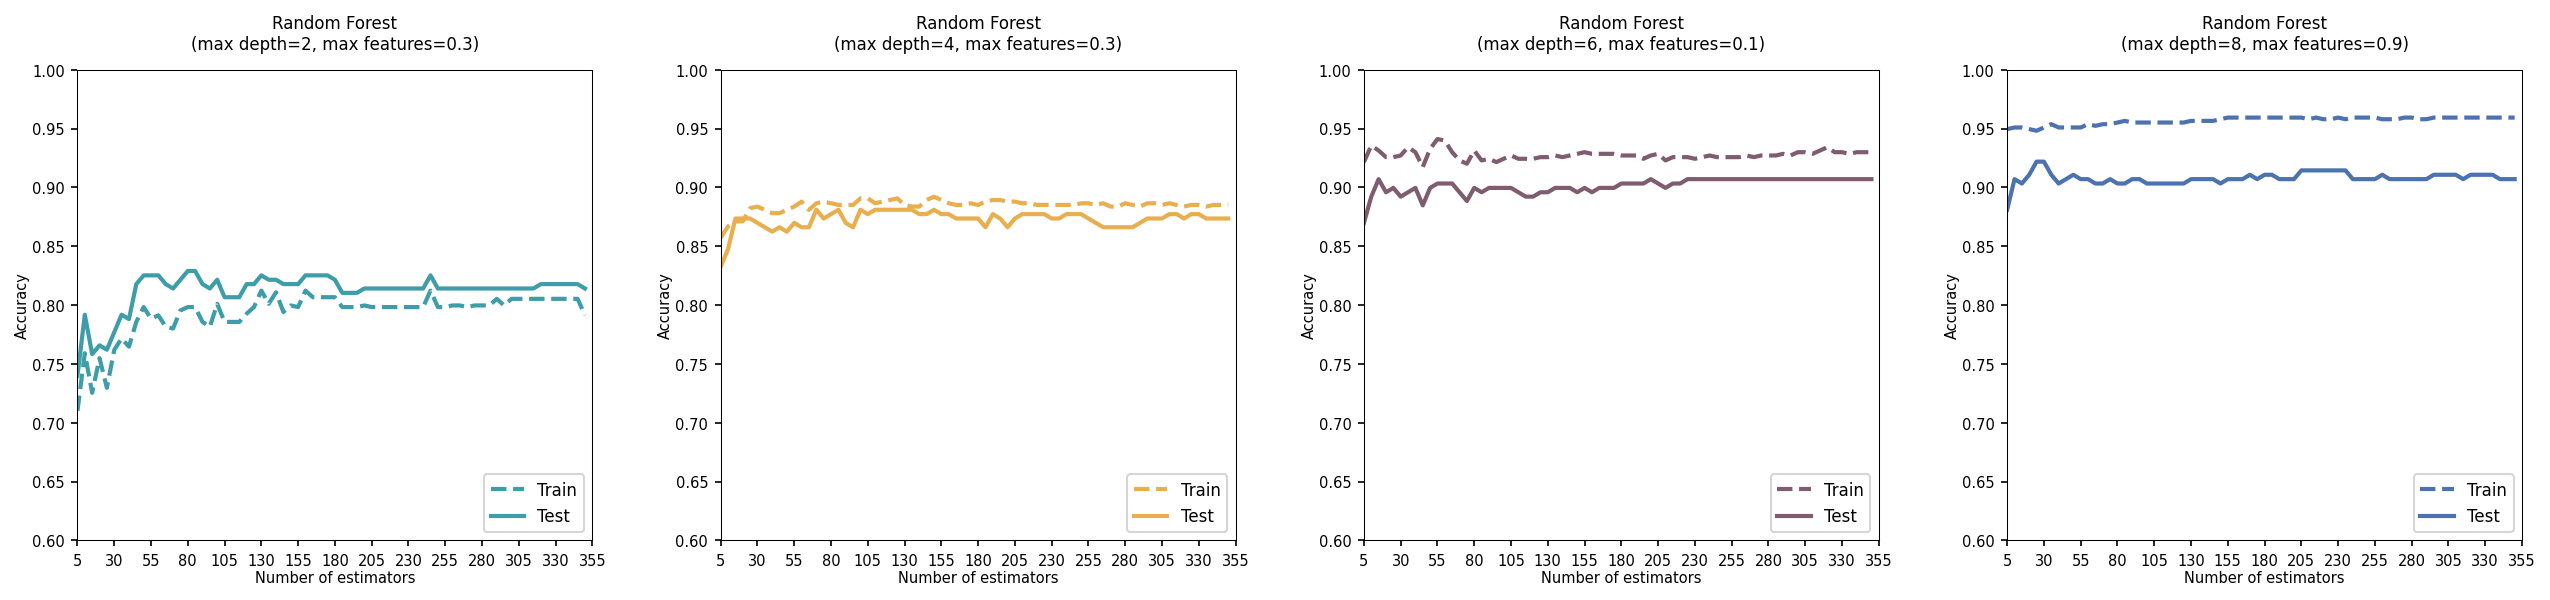

In [45]:
def random_forests_study_best_depth_max_features(
    trnX: ndarray,
    trnY: array,
    tstX: ndarray,
    tstY: array,
    depth_feature_pairs: dict,          
    nr_max_trees: int,
    lag: int,
    metric: str = "Accuracy",
) -> None:

    n_estimators = list(range(5, nr_max_trees + 1, lag))
    if n_estimators[-1] != nr_max_trees:
        n_estimators.append(nr_max_trees)
    colors = ["#3D9EA9", "#E9AE4E", "#7F5C6F", "#4C72B0", "#74aa66"]
    xticks = [5, 30, 55, 80, 105, 130, 155, 180, 205, 230, 255, 280, 305, 330, 355]

    cols = len(depth_feature_pairs)
    _, axs = subplots(1, cols, figsize=(cols * HEIGHT + 1.5, HEIGHT + 0.5), squeeze=False)

    print(f"{'Depth':>6} {'Features':>10} {'N Estimators':>14} {'Train '+metric:>15} {'Test '+metric:>15}")
    print("-" * 62)

    for i, (d, f) in enumerate(depth_feature_pairs.items()):
        y_trn_values, y_tst_values = [], []

        for n in n_estimators:
            clf = RandomForestClassifier(
                n_estimators=n, max_depth=d, max_features=f,
                bootstrap=True, oob_score=True, n_jobs=1, random_state=SEED,
            )
            clf.fit(trnX, trnY)
            eval_trn = CLASS_EVAL_METRICS[metric](trnY, clf.predict(trnX))
            eval_tst = CLASS_EVAL_METRICS[metric](tstY, clf.predict(tstX))
            y_trn_values.append(eval_trn)
            y_tst_values.append(eval_tst)
            print(f"{d:>6} {f:>10.1f} {n:>14} {eval_trn:>15.2f} {eval_tst:>15.2f}")


        print()

        color = colors[i]
        ax    = axs[0, i]

        ax.plot(n_estimators, y_trn_values, color=color, linestyle="--", linewidth=2, label="Train")
        ax.plot(n_estimators, y_tst_values, color=color, linestyle="-",  linewidth=2, label="Test")

        ax.set_title(f"Random Forest\n(max depth={d}, max features={f})", fontsize=8, pad=10)
        ax.set(xlabel="Number of estimators", ylabel=metric, xlim=(5, nr_max_trees), ylim=(0.6, 1.0))
        ax.set_xticks(xticks)
        ax.set_xticklabels([str(x) for x in xticks])
        ax.legend(fontsize=8, loc="lower right", frameon=True)
        ax.tick_params(direction="out", labelsize=7, pad=3)
        ax.xaxis.label.set_size(7)
        ax.yaxis.label.set_size(7)
        ax.set_facecolor("white")
        ax.grid(False)

        for spine in ax.spines.values():
            spine.set(visible=True, linewidth=0.5, color="black")

    axs[0, 0].get_figure().tight_layout(pad=2.5, w_pad=2.5, h_pad=2.0)


random_forests_study_best_depth_max_features(trnX, trnY, tstX, tstY, depth_feature_pairs=evaluation_pairs,nr_max_trees=350, lag=5, metric=eval_metric)
show()

In [46]:
best_depth = 6      
best_features = 0.1  
best_n = 15   

<Figure size 600x450 with 0 Axes>

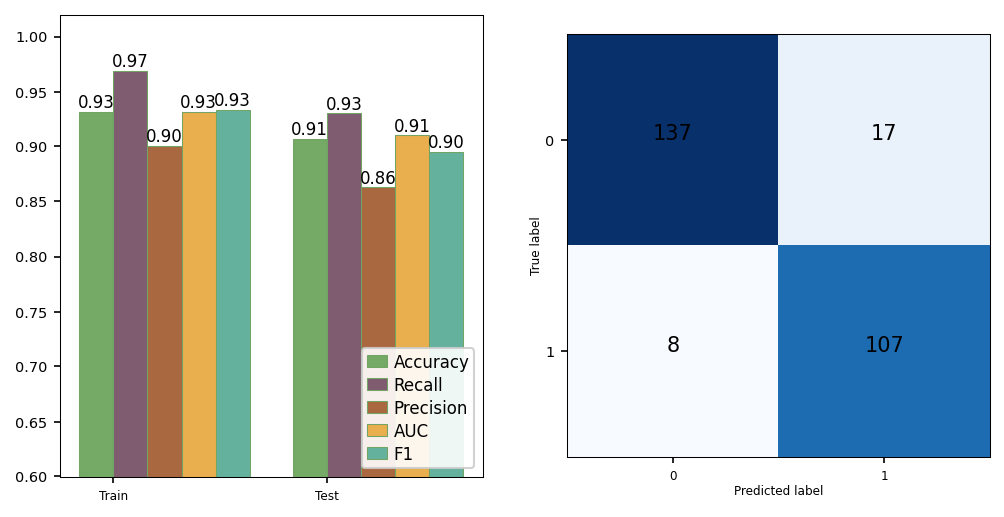

In [47]:
best_model = RandomForestClassifier(n_estimators=best_n, max_depth=best_depth, max_features=best_features,bootstrap=True, oob_score=True, n_jobs=1, random_state=SEED,)
best_model.fit(trnX, trnY)
params = {"name": "RF", "metric": eval_metric, "params": (best_depth, best_features, best_n)}
plot_model_evaluation(best_model, trnX, trnY, tstX, tstY, labels, params)

`Gradient Boosting`

 Depth     LR   N Estimators  Train Accuracy   Test Accuracy
------------------------------------------------------------
     2   0.01              5            0.72            0.75
     2   0.01             10            0.72            0.75
     2   0.01             15            0.75            0.79
     2   0.01             20            0.75            0.79
     2   0.01             25            0.77            0.74
     2   0.01             30            0.77            0.74
     2   0.01             35            0.77            0.74
     2   0.01             40            0.77            0.74
     2   0.01             45            0.77            0.74
     2   0.01             50            0.77            0.74
     2   0.01             55            0.77            0.74
     2   0.01             60            0.77            0.74
     2   0.01             65            0.77            0.74
     2   0.01             70            0.77            0.74
     2   0.01           

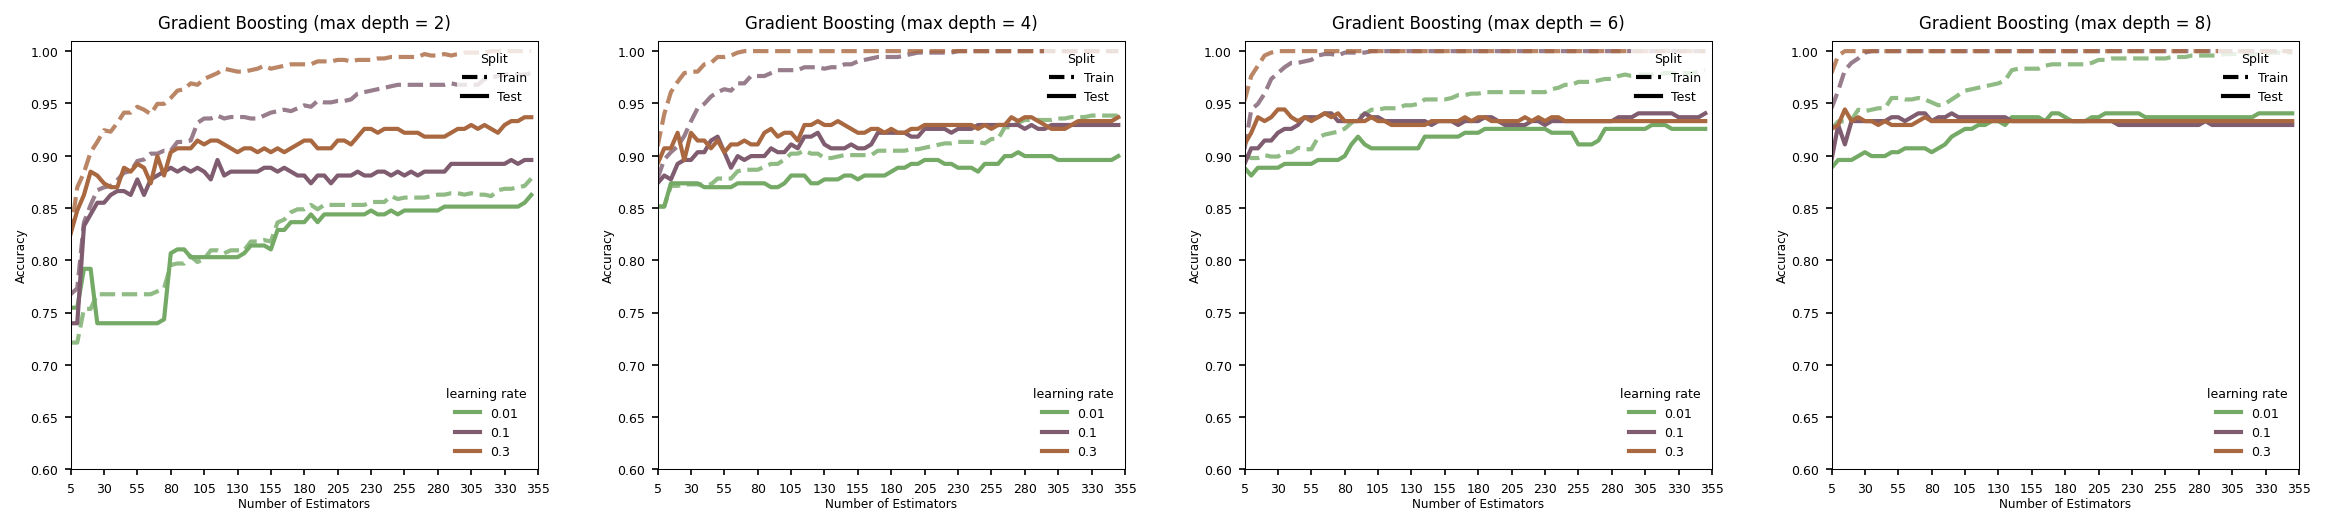

In [48]:
def gradient_boosting_study(
    trnX: ndarray,
    trnY: array,
    tstX: ndarray,
    tstY: array,
    nr_max_trees: int = 350,
    lag: int = 5,
    metric: str = "Accuracy",
) -> None:

    n_estimators   = list(range(5, nr_max_trees + 1, lag))
    if n_estimators[-1] != nr_max_trees:
        n_estimators.append(nr_max_trees)

    max_depths     = [2, 4, 6, 8]
    learning_rates = [0.01, 0.1, 0.3]
    colors         = {"0.01": "#74aa66", "0.1": "#7F5C6F", "0.3": "#A96840"}
    xticks         = list(range(5, nr_max_trees + lag + 1, 25))

    cols = len(max_depths)
    _, axs = subplots(1, cols, figsize=(cols * HEIGHT, HEIGHT), squeeze=False)

    print(f"{'Depth':>6} {'LR':>6} {'N Estimators':>14} {'Train '+metric:>15} {'Test '+metric:>15}")
    print("-" * 60)

    for i, d in enumerate(max_depths):
        values_tst, values_trn = {}, {}

        for lr in learning_rates:
            y_tst_values, y_trn_values = [], []

            for n in n_estimators:
                clf = GradientBoostingClassifier(
                    n_estimators=n,
                    max_depth=d,
                    learning_rate=lr,
                    random_state=SEED,
                )
                clf.fit(trnX, trnY)

                eval_trn = CLASS_EVAL_METRICS[metric](trnY, clf.predict(trnX))
                eval_tst = CLASS_EVAL_METRICS[metric](tstY, clf.predict(tstX))
                y_trn_values.append(eval_trn)
                y_tst_values.append(eval_tst)

                print(f"{d:>6} {lr:>6.2f} {n:>14} {eval_trn:>15.2f} {eval_tst:>15.2f}")

            key = f"{lr:g}"
            values_tst[key] = y_tst_values
            values_trn[key] = y_trn_values

        print()

        ax = axs[0, i]

        for key in values_tst:
            c = colors[key]
            ax.plot(n_estimators, values_trn[key], linestyle="--", linewidth=2, color=c, alpha=0.8)
            ax.plot(n_estimators, values_tst[key], linestyle="-", linewidth=2, color=c, alpha=1.0)

        ax.set_title(f"Gradient Boosting (max depth = {d})", fontsize=8)
        ax.set(
            xlabel="Number of Estimators",
            ylabel=metric,
            xlim=(5, nr_max_trees + lag),
            ylim=(0.6, 1.01),
        )
        ax.set_xticks(xticks)
        ax.set_xticklabels([str(x) for x in xticks])
        ax.tick_params(axis="both", which="major", labelsize=6, direction="out")
        ax.set_facecolor("white")
        ax.grid(False)

        for spine in ax.spines.values():
            spine.set(visible=True, linewidth=0.5, color="black")

        lr_legend = ax.legend(
            handles=[
                mlines.Line2D([], [], color=colors[k], lw=2, label=k)
                for k in colors
            ],
            title="learning rate",
            fontsize=6,
            title_fontsize=6,
            loc="lower right",
            frameon=True,
        )
        lr_legend.get_frame().set_edgecolor("none")
        ax.add_artist(lr_legend)

        split_legend = ax.legend(
            handles=[
                mlines.Line2D([], [], color="black", linestyle="--", lw=2, label="Train"),
                mlines.Line2D([], [], color="black", linestyle="-", lw=2, label="Test"),
            ],
            title="Split",
            fontsize=6,
            title_fontsize=6,
            loc="upper right",
            frameon=True,
        )
        split_legend.get_frame().set_edgecolor("none")

    axs[0, 0].get_figure().tight_layout(pad=2.5, w_pad=2.5)


gradient_boosting_study(
    trnX,
    trnY,
    tstX,
    tstY,
    nr_max_trees=350,
    lag=5,
    metric=eval_metric,
)
show()

In [49]:
evaluation_pairs= {
    2: 0.3,
    4: 0.3,
    6: 0.3,
    8: 0.1
}

 Depth     LR   N Estimators  Train Accuracy   Test Accuracy
------------------------------------------------------------
     2   0.30              5            0.82            0.83
     2   0.30             10            0.87            0.85
     2   0.30             15            0.88            0.86
     2   0.30             20            0.90            0.88
     2   0.30             25            0.91            0.88
     2   0.30             30            0.92            0.87
     2   0.30             35            0.92            0.87
     2   0.30             40            0.93            0.87
     2   0.30             45            0.94            0.89
     2   0.30             50            0.94            0.88
     2   0.30             55            0.95            0.89
     2   0.30             60            0.94            0.89
     2   0.30             65            0.94            0.87
     2   0.30             70            0.95            0.90
     2   0.30           

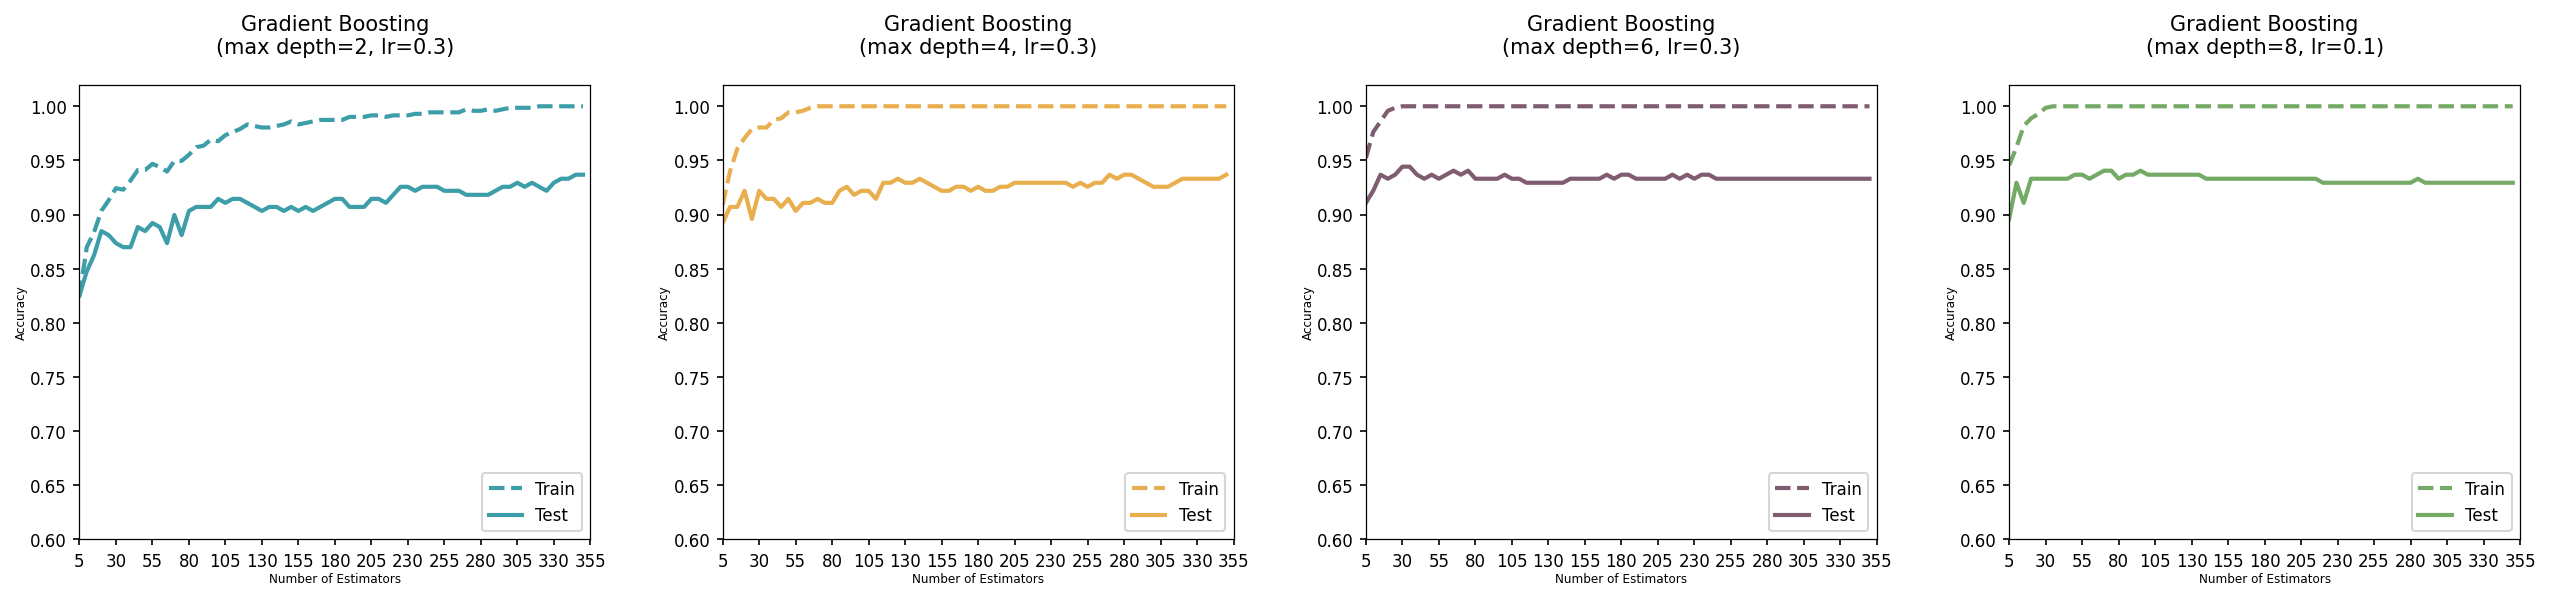

In [50]:
def gradient_boosting_study_best_depth_max_features_learning_rate(
    trnX: ndarray,
    trnY: array,
    tstX: ndarray,
    tstY: array,
    depth_lr_pairs: dict,
    nr_max_trees: int,
    lag: int,
    metric: str = "Accuracy",
) -> None:

    n_estimators = list(range(5, nr_max_trees + 1, lag))
    if n_estimators[-1] != nr_max_trees:
        n_estimators.append(nr_max_trees)

    colors = ["#3D9EA9", "#E9AE4E", "#7F5C6F", "#74AA66", "#4C72B0"]
    custom_xticks = list(range(5, nr_max_trees + lag + 1, 25))

    cols = len(depth_lr_pairs)
    _, axs = subplots(1, cols, figsize=(cols * HEIGHT + 1.5, HEIGHT + 0.5), squeeze=False)

    print(f"{'Depth':>6} {'LR':>6} {'N Estimators':>14} {'Train '+metric:>15} {'Test '+metric:>15}")
    print("-" * 60)

    for i, (d, lr) in enumerate(depth_lr_pairs.items()):
        y_trn_values, y_tst_values = [], []

        for n in n_estimators:
            clf = GradientBoostingClassifier(
                n_estimators=n,
                max_depth=d,
                learning_rate=lr,
                random_state=SEED,
            )
            clf.fit(trnX, trnY)

            eval_trn = CLASS_EVAL_METRICS[metric](trnY, clf.predict(trnX))
            eval_tst = CLASS_EVAL_METRICS[metric](tstY, clf.predict(tstX))

            y_trn_values.append(eval_trn)
            y_tst_values.append(eval_tst)

            print(f"{d:>6} {lr:>6.2f} {n:>14} {eval_trn:>15.2f} {eval_tst:>15.2f}")

        print()

        color = colors[i]
        ax = axs[0, i]

        ax.plot(n_estimators, y_trn_values, color=color, linestyle="--", linewidth=2, label="Train")
        ax.plot(n_estimators, y_tst_values, color=color, linestyle="-", linewidth=2, label="Test")

        ax.set_title(f"Gradient Boosting\n(max depth={d}, lr={lr})", fontsize=10, pad=15)
        ax.set(
            xlabel="Number of Estimators",
            ylabel=metric,
            xlim=(5, nr_max_trees + lag),
            ylim=(0.6, 1.02),
        )
        ax.set_xticks(custom_xticks)
        ax.set_xticklabels([str(x) for x in custom_xticks])
        ax.legend(fontsize=8, loc="lower right", frameon=True)
        ax.tick_params(direction="out", labelsize=8)
        ax.set_facecolor("white")
        ax.grid(False)

        for spine in ax.spines.values():
            spine.set(visible=True, linewidth=0.6, color="black")

    axs[0, 0].get_figure().tight_layout(pad=2.5, w_pad=2.5, h_pad=2.0)


gradient_boosting_study_best_depth_max_features_learning_rate(
    trnX,
    trnY,
    tstX,
    tstY,
    depth_lr_pairs=evaluation_pairs,
    nr_max_trees=350,
    lag=5,
    metric=eval_metric,
)
show()

In [51]:
best_depth = 4      
best_lr    = 0.3    
best_n     = 10     

<Figure size 600x450 with 0 Axes>

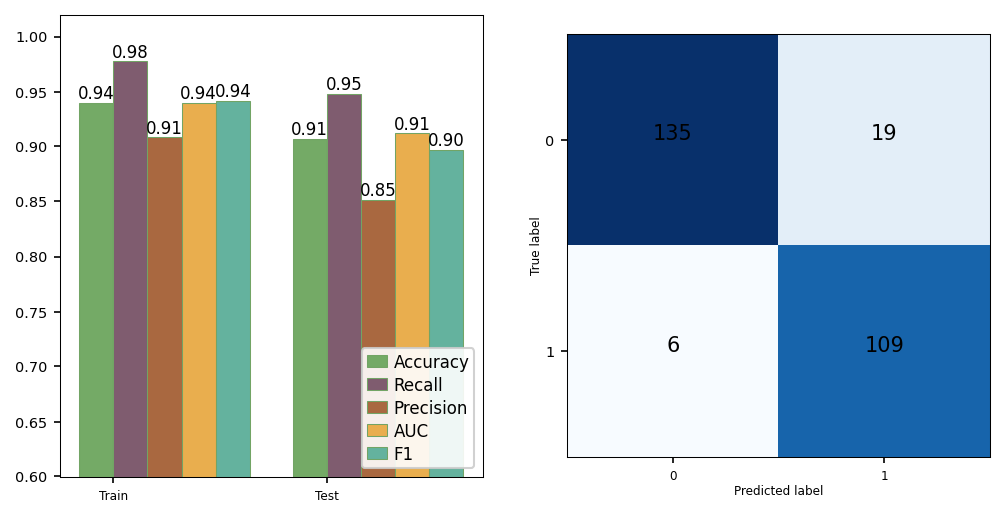

In [52]:
best_model = GradientBoostingClassifier(n_estimators=best_n, max_depth=best_depth, learning_rate=best_lr, random_state=SEED)
best_model.fit(trnX, trnY)
params = {"name": "GB", "metric": eval_metric, "params": (best_depth, best_lr, best_n)}
plot_model_evaluation(best_model, trnX, trnY, tstX, tstY, labels, params)

`MultiLayer Perceptrons (MLPs)`

LR Type       LR Init   Iterations  Train Accuracy   Test Accuracy
-----------------------------------------------------------------
constant        0.500           20            0.85            0.82
constant        0.500           40            0.85            0.84
constant        0.500           60            0.87            0.85
constant        0.500           80            0.89            0.87
constant        0.500          100            0.91            0.87
constant        0.500          120            0.93            0.88
constant        0.500          140            0.93            0.88
constant        0.500          160            0.95            0.90
constant        0.500          180            0.95            0.90
constant        0.500          200            0.95            0.90
constant        0.500          220            0.96            0.90
constant        0.500          240            0.95            0.89
constant        0.500          260            0.96            0

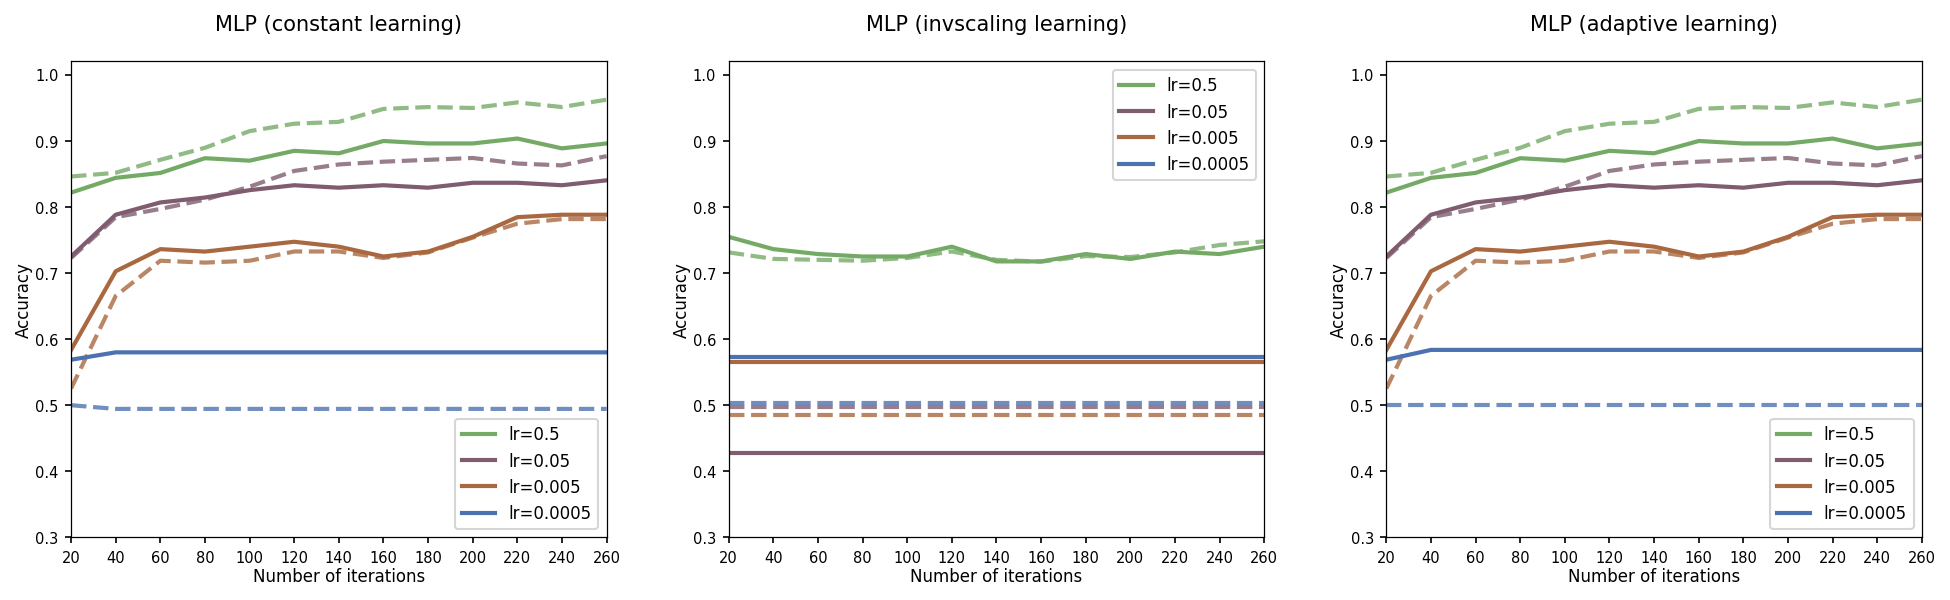

In [53]:
def mlp_study(
    trnX: ndarray,
    trnY: array,
    tstX: ndarray,
    tstY: array,
    nr_max_iterations: int,
    lag: int,
    metric: str = "Accuracy",
) -> None:

    nr_iterations = list(range(lag, nr_max_iterations + 1, lag))
    if nr_max_iterations not in nr_iterations:
        nr_iterations.append(nr_max_iterations)

    lr_types: list[Literal["constant", "invscaling", "adaptive"]] = ["constant", "invscaling", "adaptive"]
    learning_rates = [0.5, 0.05, 0.005, 0.0005]
    colors = {"0.5": "#74AA66", "0.05": "#7F5C6F", "0.005": "#A96840", "0.0005": "#4C72B0"}

    cols = len(lr_types)
    _, axs = subplots(1, cols, figsize=(cols * HEIGHT + 1.5, HEIGHT + 0.5), squeeze=False)

    print(f"{'LR Type':<12} {'LR Init':>8} {'Iterations':>12} {'Train '+metric:>15} {'Test '+metric:>15}")
    print("-" * 65)

    for i, lr_type in enumerate(lr_types):
        values_tst, values_trn = {}, {}

        for lr in learning_rates:
            y_trn_values, y_tst_values = [], []

            for n in nr_iterations:
                clf = MLPClassifier(
                    learning_rate=lr_type,
                    learning_rate_init=lr,
                    max_iter=n,
                    activation="logistic",
                    solver="sgd",
                    random_state=SEED,
                    hidden_layer_sizes=(50,),
                    verbose=False,
                    warm_start= True
                )
                clf.fit(trnX, trnY)
                eval_trn = CLASS_EVAL_METRICS[metric](trnY, clf.predict(trnX))
                eval_tst = CLASS_EVAL_METRICS[metric](tstY, clf.predict(tstX))
                y_trn_values.append(eval_trn)
                y_tst_values.append(eval_tst)
                print(f"{lr_type:<12} {lr:>8.3f} {n:>12} {eval_trn:>15.2f} {eval_tst:>15.2f}")
               

            key = f"{lr:g}"
            values_tst[key] = y_tst_values
            values_trn[key] = y_trn_values

        print()

        ax = axs[0, i]

        for key in values_tst:
            c = colors[key]
            ax.plot(nr_iterations, values_trn[key], linestyle="--", linewidth=2, color=c, alpha=0.8)
            ax.plot(nr_iterations, values_tst[key],  linestyle="-",  linewidth=2, color=c, alpha=1.0)

        ax.set_title(f"MLP ({lr_type} learning)", fontsize=10, pad=15)
        ax.set_xlabel("Number of iterations", fontsize=8)
        ax.set_ylabel(metric, fontsize=8)
        ax.set_ylim(0.3, 1.02)
        ax.set_facecolor("white")
        ax.grid(False)

        for spine in ax.spines.values():
            spine.set(visible=True, linewidth=0.6, color="black")

        legend_loc = "upper right" if lr_type == "invscaling" else "lower right"
        lr_legend = ax.legend(
            handles=[mlines.Line2D([], [], color=colors[k], lw=2, label=f"lr={k}") for k in colors],
            fontsize=8, loc=legend_loc, frameon=True,
        )

    for ax_row in axs:
        for ax in ax_row:
            ax.set_xlim(left=20, right=260)
            ax.xaxis.set_major_locator(MultipleLocator(20))
            ax.tick_params(direction="out", labelsize=7, pad=3)
    axs[0, 0].get_figure().tight_layout(pad=2.5, w_pad=2.5)

mlp_study(trnX, trnY, tstX, tstY, nr_max_iterations=260, lag=20, metric=eval_metric,)
show()

In [54]:
evaluation_pairs = {
    "constant":   0.5,
    "invscaling": 0.5,
    "adaptive":   0.5,
}

LR Type       LR Init   Iterations  Train Accuracy   Test Accuracy
-----------------------------------------------------------------
constant        0.500           20            0.85            0.82
constant        0.500           40            0.85            0.84
constant        0.500           60            0.87            0.85
constant        0.500           80            0.89            0.87
constant        0.500          100            0.91            0.87
constant        0.500          120            0.93            0.88
constant        0.500          140            0.93            0.88
constant        0.500          160            0.95            0.90
constant        0.500          180            0.95            0.90
constant        0.500          200            0.95            0.90
constant        0.500          220            0.96            0.90
constant        0.500          240            0.95            0.89
constant        0.500          260            0.96            0

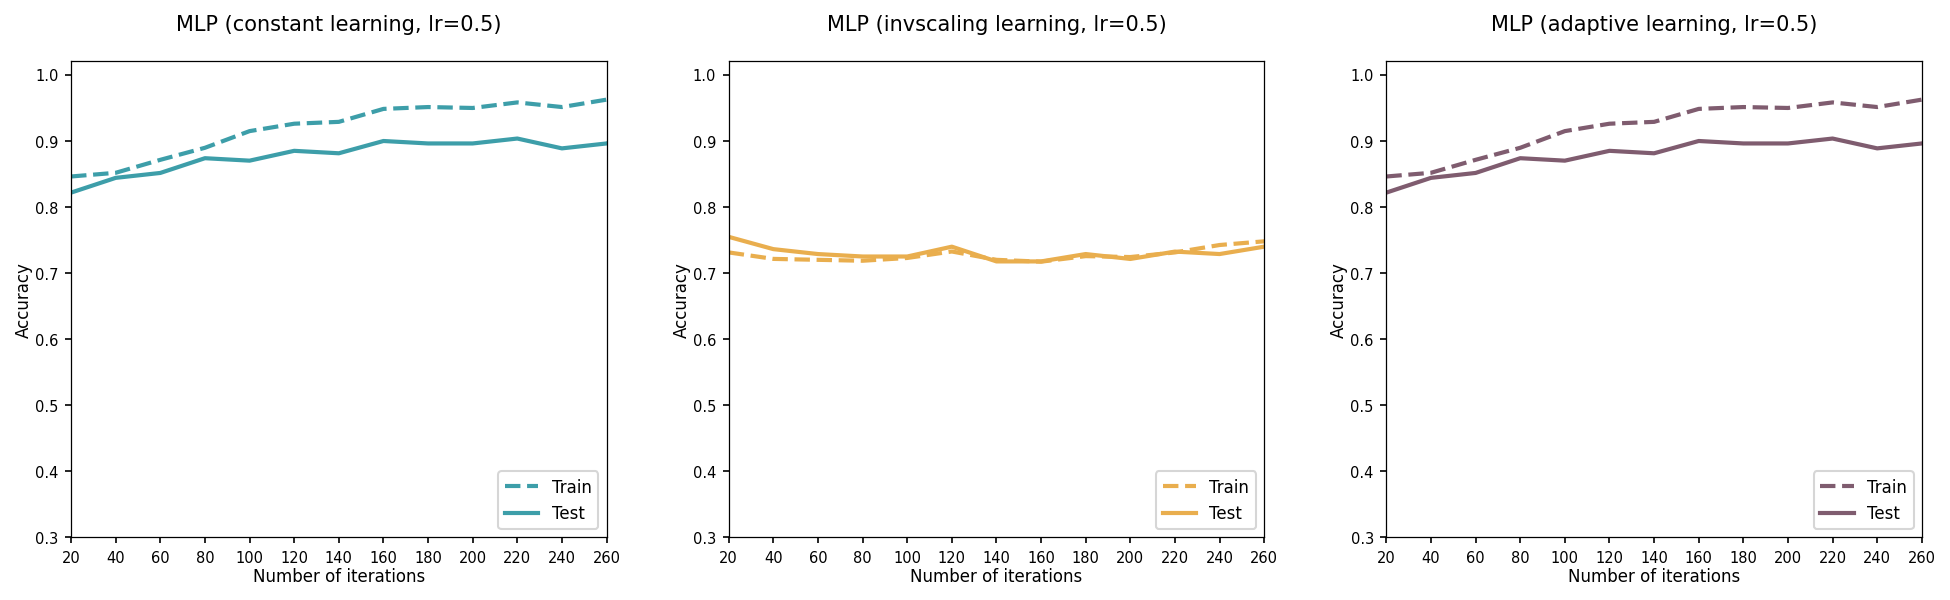

In [55]:
def mlp_study_pairs(
    trnX: ndarray,
    trnY: array,
    tstX: ndarray,
    tstY: array,
    lr_type_lr_pairs: dict,             
    nr_max_iterations: int,
    lag: int,
    metric: str = "Accuracy",
) -> None:

    nr_iterations = list(range(lag, nr_max_iterations + 1, lag))
    if nr_max_iterations not in nr_iterations:
        nr_iterations.append(nr_max_iterations)

    colors = ["#3D9EA9", "#E9AE4E", "#7F5C6F", "#74AA66", "#4C72B0"]

    cols = len(lr_type_lr_pairs)
    _, axs = subplots(1, cols, figsize=(cols * HEIGHT + 1.5, HEIGHT + 0.5), squeeze=False)

    print(f"{'LR Type':<12} {'LR Init':>8} {'Iterations':>12} {'Train '+metric:>15} {'Test '+metric:>15}")
    print("-" * 65)

    for i, (lr_type, lr_init) in enumerate(lr_type_lr_pairs.items()):
        y_trn_values, y_tst_values = [], []

        for n in nr_iterations:
            clf = MLPClassifier(
                learning_rate=lr_type,
                learning_rate_init=lr_init,
                max_iter=n,
                activation="logistic",
                solver="sgd",
                random_state=SEED,
                hidden_layer_sizes=(50,),
                verbose=False,
                warm_start= True,
            )
            clf.fit(trnX, trnY)
            eval_trn = CLASS_EVAL_METRICS[metric](trnY, clf.predict(trnX))
            eval_tst = CLASS_EVAL_METRICS[metric](tstY, clf.predict(tstX))
            y_trn_values.append(eval_trn)
            y_tst_values.append(eval_tst)
            print(f"{lr_type:<12} {lr_init:>8.3f} {n:>12} {eval_trn:>15.2f} {eval_tst:>15.2f}")

        print()

        color = colors[i]
        ax    = axs[0, i]

        ax.plot(nr_iterations, y_trn_values, linestyle="--", color=color, linewidth=2, label="Train")
        ax.plot(nr_iterations, y_tst_values, linestyle="-",  color=color, linewidth=2, label="Test")

        ax.set_title(f"MLP ({lr_type} learning, lr={lr_init})", fontsize=10, pad=15)
        ax.set_xlabel("Number of iterations", fontsize=8)
        ax.set_ylabel(metric, fontsize=8)
        ax.set_ylim(0.3, 1.02)
        ax.legend(fontsize=8, loc="lower right", frameon=True)
        ax.set_facecolor("white")
        ax.grid(False)

        for spine in ax.spines.values():
            spine.set(visible=True, linewidth=0.6, color="black")

    for ax_row in axs:
        for ax in ax_row:
            ax.set_xlim(left=20, right=260)
            ax.xaxis.set_major_locator(MultipleLocator(20))
            ax.tick_params(direction="out", labelsize=7, pad=3)
    axs[0, 0].get_figure().tight_layout(pad=2.5, w_pad=2.5)


mlp_study_pairs(trnX, trnY, tstX, tstY, lr_type_lr_pairs=evaluation_pairs, nr_max_iterations=300, lag=20, metric=eval_metric)
show()

In [56]:
best_lr_type = "constant"   
best_lr      = 0.5          
best_iter    = 200         

<Figure size 600x450 with 0 Axes>

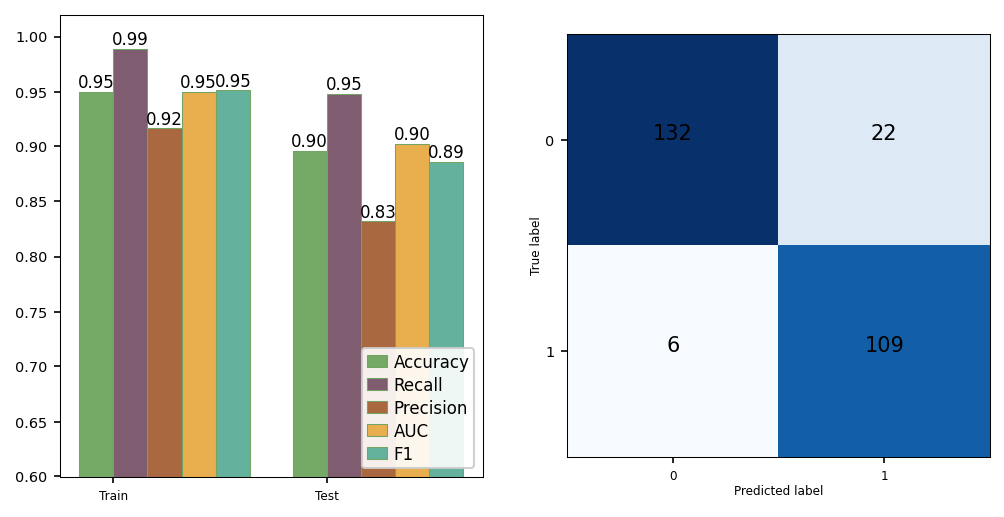

In [57]:
best_model = MLPClassifier(learning_rate=best_lr_type, learning_rate_init=best_lr, max_iter=best_iter, activation="logistic", solver="sgd",random_state=SEED,hidden_layer_sizes=(50,),verbose=False)
best_model.fit(trnX, trnY)
params = {"name": "MLP", "metric": eval_metric, "params": (best_lr_type, best_lr, best_iter)}
plot_model_evaluation(best_model, trnX, trnY, tstX, tstY, labels, params)

`Logistic Regression`

Penalty      Iterations  Train Accuracy   Test Accuracy
------------------------------------------------------
L1                    1          0.8011          0.7993
L1                    2          0.8361          0.7993
L1                    3          0.8319          0.8141
L1                    4          0.8669          0.8401
L1                    5          0.8725          0.8401
L1                    6          0.8613          0.8290
L1                    7          0.8599          0.8327
L1                    8          0.8613          0.8364
L1                    9          0.8613          0.8364
L1                   10          0.8613          0.8364
L1                   11          0.8613          0.8364
L1                   12          0.8613          0.8364
L1                   13          0.8613          0.8364
L1                   14          0.8613          0.8364
L1                   15          0.8613          0.8364
L1                   16          0.8613          

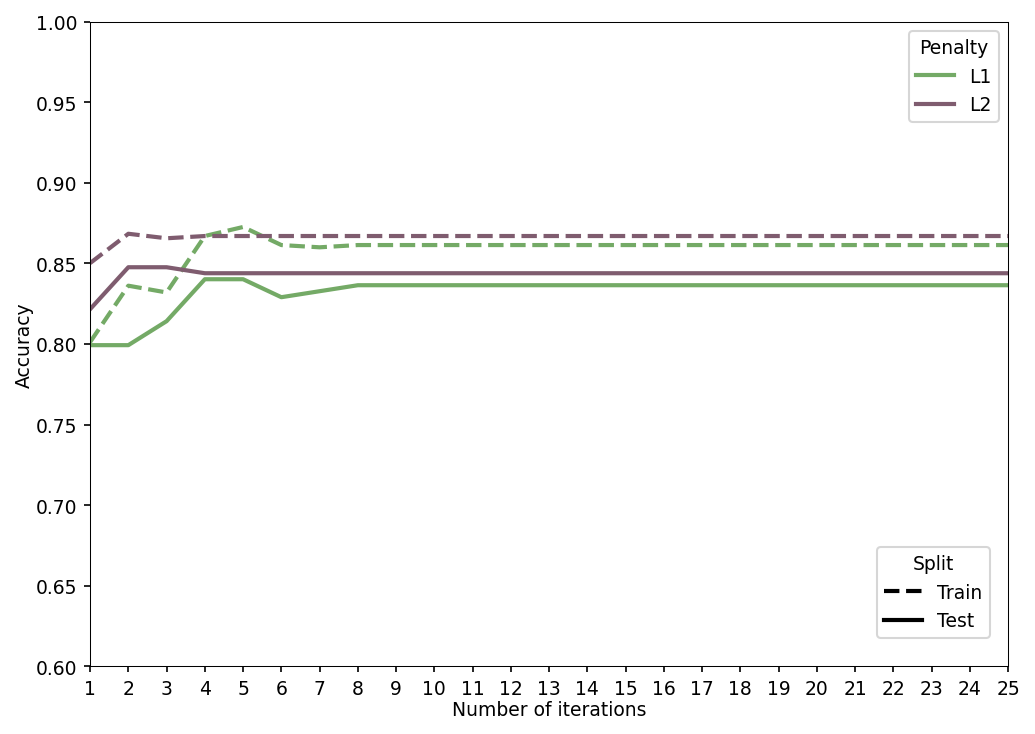

In [58]:
def logistic_regression_study(
    trnX: ndarray,
    trnY: array,
    tstX: ndarray,
    tstY: array,
    nr_max_iterations: int,
    lag: int,
    metric: str = "Accuracy",
) -> None:

    nr_iterations = list(range(lag, nr_max_iterations + 1, lag))
    if nr_iterations[-1] != nr_max_iterations:
        nr_iterations.append(nr_max_iterations)

    penalties = ["l1", "l2"]
    colors = {"L1": "#74aa66", "L2": "#7F5C6F"}

    values_train, values_test = {}, {}

    print(f"{'Penalty':<12} {'Iterations':>10} {'Train '+metric:>15} {'Test '+metric:>15}")
    print("-" * 54)

    for p in penalties:
        label = p.upper()
        train_values, test_values = [], []

        for n in nr_iterations:
            clf = LogisticRegression(
                penalty=p,
                max_iter=n,
                solver="liblinear",
                random_state=SEED,
            )
            clf.fit(trnX, trnY)

            train_score = CLASS_EVAL_METRICS[metric](trnY, clf.predict(trnX))
            test_score = CLASS_EVAL_METRICS[metric](tstY, clf.predict(tstX))

            train_values.append(train_score)
            test_values.append(test_score)

            print(f"{label:<12} {n:>10} {train_score:>15.4f} {test_score:>15.4f}")

        values_train[label] = train_values
        values_test[label] = test_values

    fig, ax = subplots(figsize=(7, 5))

    for label in values_test.keys():
        ax.plot(nr_iterations, values_test[label], color=colors[label], linestyle="-", label=label)
        ax.plot(nr_iterations, values_train[label], color=colors[label], linestyle="--")

    ax.set_xlabel("Number of iterations", fontsize=9)
    ax.set_ylabel(metric, fontsize=9)
    ax.set_xlim(min(nr_iterations), nr_max_iterations)
    ax.set_ylim(0.6, 1.0)
    ax.set_xticks(nr_iterations)
    ax.set_xticklabels([str(x) for x in nr_iterations])
    ax.grid(False)
    ax.tick_params(axis="both", which="major", labelsize=9, direction="out")

    for spine in ax.spines.values():
        spine.set(visible=True, linewidth=0.5, color="black")

    penalty_legend = ax.legend(
        title="Penalty",
        fontsize=9,
        title_fontsize=9,
        loc="upper right",
    )
    ax.add_artist(penalty_legend)

    ax.legend(
        handles=[
            Line2D([0], [0], color="black", linestyle="--", label="Train"),
            Line2D([0], [0], color="black", linestyle="-", label="Test"),
        ],
        title="Split",
        fontsize=9,
        title_fontsize=9,
        loc="lower right",
        bbox_to_anchor=(0.99, 0.03),
    )

    fig.tight_layout()


logistic_regression_study(
    trnX,
    trnY,
    tstX,
    tstY,
    nr_max_iterations=25,
    lag=1,
    metric=eval_metric,
)
show()

In [59]:
best_penalty = "l2"
best_n_iter = 3

<Figure size 600x450 with 0 Axes>

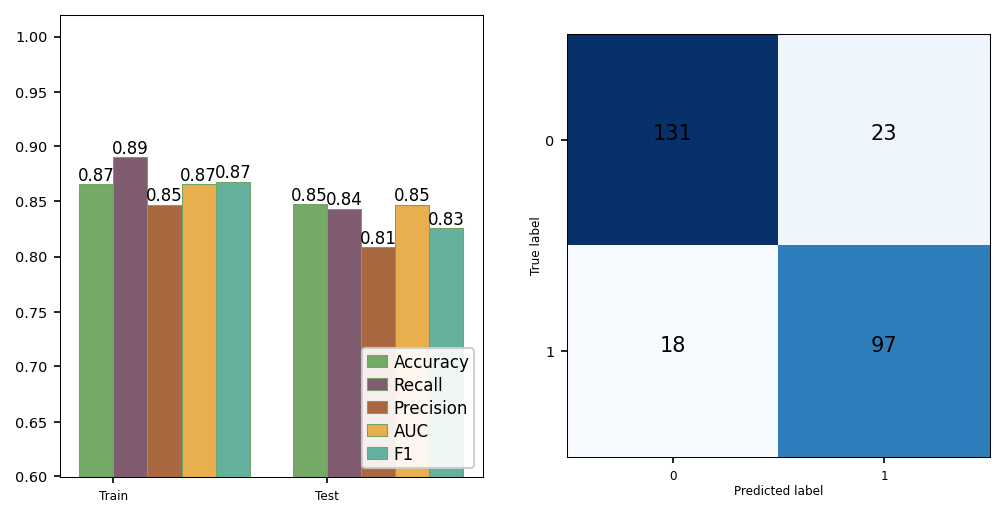

In [60]:
best_model = LogisticRegression(penalty=best_penalty, max_iter=best_n_iter, solver="liblinear", random_state=SEED)
best_model.fit(trnX, trnY)
params = {"name": "LR", "metric": eval_metric, "params": (best_penalty, best_n_iter)}
plot_model_evaluation(best_model, trnX, trnY, tstX, tstY, labels, params)

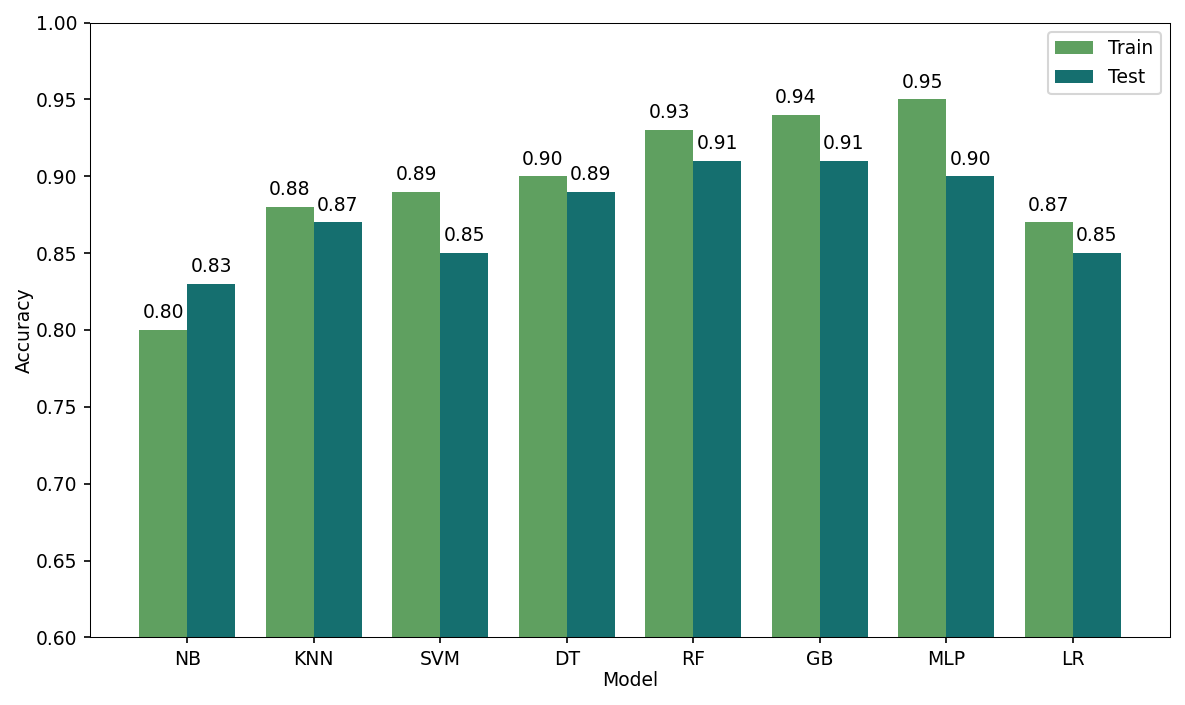

In [ ]:
models = ['NB', 'KNN', 'SVM', 'DT', 'RF', 'GB', 'MLP', 'LR']
train = [0.80, 0.88, 0.89, 0.90, 0.93, 0.94, 0.95, 0.87]
test  = [0.83, 0.87, 0.85, 0.89, 0.91, 0.91, 0.90, 0.85]

x = np.arange(len(models))
width = 0.38

fig, ax = plt.subplots(figsize=(8, 4.8))

color_train = '#5FA060'
color_test  = '#156F6F'

bars1 = ax.bar(x - width/2, train, width, label='Train', color=color_train, edgecolor='none')
bars2 = ax.bar(x + width/2, test,  width, label='Test',  color=color_test,  edgecolor='none')

for bars, values in [(bars1, train), (bars2, test)]:
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Model', fontsize=9)
ax.set_ylabel('Accuracy', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9)
ax.set_ylim(0.60, 1.00)
ax.set_yticks(np.arange(0.60, 1.01, 0.05))
ax.tick_params(axis='both', which='both', direction='out',
               length=3, width=0.8, labelsize=9)
ax.legend(loc='upper right', frameon=True, fontsize=9)


for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('black')
ax.grid(False)

plt.tight_layout()
plt.show()